# Laboratorio 6 - Análisis de redes sociales

**CC3084 - Data Science · Semestre II, 2026**  
**Integrantes:** Daniel Chet - 231177 · Dulce Ambrosio - 231143 · Javier Linares - 231135

Entrega final reproducible de los ejercicios 1-10. El análisis conserva los datos crudos y los textos en su idioma original; no se traduce el contenido.

## 0. Configuración reproducible

El cuaderno puede ejecutarse desde la carpeta del laboratorio o desde `notebooks/`. Las funciones reutilizables viven en `src/`; los datos crudos solo se leen y las salidas se escriben en `data/processed/`.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd
import scipy
from scipy.stats import spearmanr
import seaborn as sns
from IPython.display import Markdown, display

%matplotlib inline

cwd = Path.cwd().resolve()
if (cwd / "data" / "raw").exists():
    ROOT = cwd
elif (cwd.parent / "data" / "raw").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Ejecute el notebook desde la carpeta del laboratorio o notebooks/.")

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import COMMENTS_SENTIMENT, MODEL_CACHE, PROCESSED_DIR
from data_processing import (
    clean_text_record, cleaning_effect, column_quality,
    cross_dataset_consistency, dataset_quality_summary,
    frequency_table, integrate_data, list_frequency_table,
    load_raw_data, mapping_ambiguities, outlier_summary,
    prepare_comments, prepare_videos, save_processed,
)
from network_analysis import (
    build_bipartite_graph, build_network_tables, build_projections,
    centrality_table, degree_distribution, detect_video_communities,
    network_summary, projection_edge_table, save_advanced_network_tables,
    save_network_tables,
)
from sentiment_analysis import MODEL_NAME, analyze_sentiment

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"author": "#2A9D8F", "video": "#E76F51", "accent": "#264653"}

versions = pd.Series({
    "Python": platform.python_version(), "pandas": pd.__version__,
    "NumPy": np.__version__, "SciPy": scipy.__version__, "NetworkX": nx.__version__,
}, name="versión")
display(versions.to_frame())
print(f"Raíz del laboratorio: {ROOT}")

,versión
Python,3.13.14
pandas,3.0.5
NumPy,2.5.2
SciPy,1.18.1
NetworkX,3.6.1


Raíz del laboratorio: C:\UVG\Semestre8\CC3084 - Data Science\Tareas\Lab6-AnaliticadeRedesSociales\CC3084-Data-Science\06_analisis_redes_sociales


# 1. Carga, comprensión e integración de los datos

## 1.1 Carga y contratos de entrada

La carga valida que estén todas las columnas descritas por el enunciado y que `video_id` y `comment_id` sean llaves primarias. Si un contrato falla, el flujo se detiene antes de producir resultados derivados.

In [2]:
videos_raw, comments_raw = load_raw_data()

dimensions = pd.DataFrame({
    "dataset": ["youtube_videos.csv", "youtube_comments.csv"],
    "filas": [len(videos_raw), len(comments_raw)],
    "columnas": [videos_raw.shape[1], comments_raw.shape[1]],
})
display(dimensions)
display(videos_raw[["video_id", "title", "channel_name", "channel_id", "view_count"]].head(3))
display(comments_raw[["comment_id", "video_id", "author_name", "author_channel_id", "text"]].head(3))

,dataset,filas,columnas
0,youtube_videos.csv,293,20
1,youtube_comments.csv,406,17


,video_id,title,channel_name,channel_id,view_count
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana en Guatemala,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,2357
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA DE DETERIORO INSTITUCIONAL,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,4
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,29736


,comment_id,video_id,author_name,author_channel_id,text
0,Ugw-J65a1iYL9hqhELh4AaABAg,j43HgwYFKfk,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel
1,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,06mFNPU0aB8,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le gusta del otro vando , por ir..."
2,Ugw0xaOb2CYXXoudtwJ4AaABAg,j43HgwYFKfk,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila"


## 1.2 Unidad de observación, llaves y variables relevantes

| Archivo | Unidad de observación | Llave primaria | Llaves/variables relacionales |
|---|---|---|---|
| `youtube_videos.csv` | un video | `video_id` | `channel_id`, `category`, `source_query` |
| `youtube_comments.csv` | un comentario principal | `comment_id` | `video_id` (foránea), `channel_id`, `author_channel_id` |

Los nombres y handles son atributos para mostrar; los IDs permanecen como identificadores. La definición de las 37 variables originales y las derivadas está en `codebook.md`.

In [3]:
key_audit = pd.DataFrame([
    {"dataset": "videos", "llave": "video_id",
     "faltantes": int(videos_raw["video_id"].isna().sum()),
     "duplicadas": int(videos_raw["video_id"].duplicated().sum()),
     "es_llave_primaria": videos_raw["video_id"].notna().all() and videos_raw["video_id"].is_unique},
    {"dataset": "comentarios", "llave": "comment_id",
     "faltantes": int(comments_raw["comment_id"].isna().sum()),
     "duplicadas": int(comments_raw["comment_id"].duplicated().sum()),
     "es_llave_primaria": comments_raw["comment_id"].notna().all() and comments_raw["comment_id"].is_unique},
])
display(key_audit)

,dataset,llave,faltantes,duplicadas,es_llave_primaria
0,videos,video_id,0,0,True
1,comentarios,comment_id,0,0,True


## 1.3 Relación entre las entidades

```text
canal (channel_id)
  └── publica → video (video_id)
                   ├── pertenece a → categoría
                   ├── fue recuperado por → consulta de búsqueda
                   └── recibe → comentario (comment_id)
                                      └── escrito por → autor (author_channel_id)
```

El `channel_id` del comentario identifica al canal propietario del video; **no** al autor. El autor se identifica con `author_channel_id`. Un autor puede comentar varios videos y un video puede recibir comentarios de varios autores, lo que motiva la red bipartita del ejercicio 4.

## 1.4 Integración por `video_id`

Se usa un `left join` desde comentarios hacia videos y se exige una relación `many_to_one`: cada comentario puede encontrar como máximo un video porque `video_id` es único en la tabla de videos.

In [4]:
join_check = comments_raw[["comment_id", "video_id"]].merge(
    videos_raw[["video_id", "title"]], on="video_id", how="left",
    validate="many_to_one", indicator=True,
)
integration_audit = join_check["_merge"].value_counts(dropna=False).rename_axis("resultado").reset_index(name="comentarios")
integration_audit["porcentaje"] = 100 * integration_audit["comentarios"] / len(join_check)
display(integration_audit)

linked = int(join_check["_merge"].eq("both").sum())
display(Markdown(
    f"**Resultado:** {linked} de {len(join_check)} comentarios "
    f"({linked / len(join_check):.1%}) pudieron asociarse con un video."
))

,resultado,comentarios,porcentaje
0,both,406,100.0
1,left_only,0,0.0
2,right_only,0,0.0


**Resultado:** 406 de 406 comentarios (100.0%) pudieron asociarse con un video.

# 2. Calidad, limpieza y preprocesamiento

## 2.1 Diagnóstico inicial

El diagnóstico cubre dimensiones, tipos, faltantes, duplicados, variables constantes y totalmente vacías. Los atípicos se detectan con la regla de 1.5 veces el rango intercuartílico; se reportan, pero no se eliminan automáticamente porque un video viral o un comentario muy respondido puede ser una observación válida.

In [5]:
general_quality = pd.concat([
    dataset_quality_summary(videos_raw, "videos", "video_id"),
    dataset_quality_summary(comments_raw, "comentarios", "comment_id"),
], ignore_index=True)
column_diagnostics = pd.concat([
    column_quality(videos_raw, "videos"),
    column_quality(comments_raw, "comentarios"),
], ignore_index=True)

display(general_quality)
display(column_diagnostics[["dataset", "variable", "dtype"]])
display(column_diagnostics.loc[
    column_diagnostics["faltantes"].gt(0)
    | column_diagnostics["constante"]
    | column_diagnostics["totalmente_vacia"]
].sort_values(["dataset", "porcentaje_faltante"], ascending=[True, False]))

,dataset,filas,columnas,filas_duplicadas,llave_duplicada,variables_constantes,variables_totalmente_vacias
0,videos,293,20,0,0,ninguna,ninguna
1,comentarios,406,17,0,0,is_pinned,viewer_rating


,dataset,variable,dtype
0,videos,video_id,str
1,videos,title,str
2,videos,channel_name,str
3,videos,channel_id,str
4,videos,source_query,str
5,videos,source_group,str
6,videos,dataset_sources,str
7,videos,channel_handle,str
8,videos,published_time,str
9,videos,view_count_text,str


,dataset,variable,dtype,faltantes,porcentaje_faltante,valores_unicos,constante,totalmente_vacia
36,comentarios,viewer_rating,float64,406,100.00,0,False,True
35,comentarios,is_pinned,bool,0,0.00,1,True,False
14,videos,description,str,26,8.87,234,False,False
10,videos,description_snippet,str,25,8.53,236,False,False
8,videos,published_time,str,13,4.44,80,False,False
9,videos,view_count_text,str,13,4.44,259,False,False


In [6]:
videos = prepare_videos(videos_raw)
comments = prepare_comments(comments_raw)
integrated = integrate_data(comments, videos)

outliers = pd.concat([
    outlier_summary(videos, ["view_count", "view_count_text_num"], "videos"),
    outlier_summary(comments, ["like_count", "reply_count"], "comentarios"),
], ignore_index=True)
display(outliers.round(2))

,dataset,variable,minimo,q1,mediana,q3,maximo,limite_inferior_iqr,limite_superior_iqr,atipicos_iqr
0,videos,view_count,2,215.0,1175.0,7465.0,8190449,-10660.00,18340.00,49
1,videos,view_count_text_num,2,215.0,1274.0,7778.5,8190449,-11130.25,19123.75,49
2,comentarios,like_count,1,1.0,2.0,4.0,405,-3.50,8.50,34
3,comentarios,reply_count,0,0.0,0.0,0.0,7,0.00,0.00,30


Los conteos presentan colas derechas largas: pocas observaciones concentran muchas visualizaciones, respuestas o me gusta. Por eso se conservan y las visualizaciones posteriores usan `log1p` cuando corresponde. La regla IQR identifica rareza estadística, no errores de captura.

### Consistencia entre IDs, nombres y handles

Un ID puede tener distintas etiquetas visibles porque un usuario puede cambiar su nombre o porque la recolección integró fuentes distintas. Se auditan esas ambigüedades sin reemplazar los IDs. También se comparan título y canal redundantes en comentarios con la tabla de videos.

In [7]:
mapping_checks = pd.concat([
    mapping_ambiguities(videos, "videos", "channel_id", "channel_name"),
    mapping_ambiguities(videos, "videos", "channel_id", "channel_handle"),
    mapping_ambiguities(videos, "videos", "channel_id", "owner_handle"),
    mapping_ambiguities(comments, "comentarios", "author_channel_id", "author_name"),
    mapping_ambiguities(comments, "comentarios", "author_channel_id", "author_handle"),
], ignore_index=True)
display(mapping_checks)
display(cross_dataset_consistency(comments, videos))

,dataset,id,etiqueta,ids_con_multiples_etiquetas,maximo_etiquetas_por_id
0,videos,channel_id,channel_name,0,1
1,videos,channel_id,channel_handle,0,1
2,videos,channel_id,owner_handle,0,1
3,comentarios,author_channel_id,author_name,0,1
4,comentarios,author_channel_id,author_handle,0,1


,variable_comentarios,variable_referencia_videos,comparables,diferencias
0,video_title,title_ref,406,0
1,channel_id,channel_id_ref,406,0
2,channel_name,channel_name_ref,406,0


## 2.2 Variables problemáticas o de uso delicado

| Variable | Tratamiento y precaución |
|---|---|
| `viewer_rating` | totalmente vacía; se documenta y no se analiza. |
| `is_pinned` | constante en la muestra; no explica variación. |
| `published_time`, `published_text` | tiempos relativos; no se convierten en fechas exactas. |
| `reply_count` | se usa como conteo, nunca como arista entre autores. |
| `like_count_text` vacío | se conserva como desconocido (`NA`), no como cero. |
| `source_query`, `source_group` | describen el muestreo; no equivalen necesariamente al tema real. |
| nombres y handles | pueden cambiar o repetirse; se muestran como etiquetas pero no identifican nodos. |
| visualizaciones, me gusta y respuestas | fotografías del momento de recolección, no conteos finales. |
| `upload_date` | se audita frente a `publish_date`; no se considera una medición independiente si coinciden. |

## 2.3 Normalización de identificadores y nombres

Solo se recortan espacios externos en IDs. En nombres y handles también se colapsan espacios repetidos. No se cambian mayúsculas internas, acentos ni contenido semántico y nunca se sustituye un ID por una etiqueta visible.

In [8]:
normalization_rows = []
for dataset, raw, clean, columns in [
    ("videos", videos_raw, videos, ["video_id", "channel_id", "title", "channel_name", "channel_handle"]),
    ("comentarios", comments_raw, comments, ["video_id", "comment_id", "channel_id", "author_channel_id", "author_name", "author_handle"]),
]:
    for column in columns:
        before = raw[column].astype("string").fillna("<NA>")
        after = clean[column].astype("string").fillna("<NA>")
        normalization_rows.append({
            "dataset": dataset, "variable": column,
            "valores_modificados": int(before.ne(after).sum()),
        })
display(pd.DataFrame(normalization_rows))

,dataset,variable,valores_modificados
0,videos,video_id,0
1,videos,channel_id,0
2,videos,title,20
3,videos,channel_name,1
4,videos,channel_handle,0
5,comentarios,video_id,0
6,comentarios,comment_id,0
7,comentarios,channel_id,0
8,comentarios,author_channel_id,0
9,comentarios,author_name,0


## 2.4 Conversión de conteos almacenados como texto

El conversor elimina separadores de miles y reconoce abreviaturas (`k`, `mil`, `m`, `millón/es`). Un valor vacío o no interpretable queda como `NA`. `view_count`, que ya es numérico, funciona como referencia para auditar `view_count_text_num`.

In [9]:
view_nonempty = videos_raw["view_count_text"].astype("string").fillna("").str.strip().ne("")
like_nonempty = comments_raw["like_count_text"].astype("string").fillna("").str.strip().ne("")
view_comparable = videos["view_count_text_num"].notna() & videos["view_count"].notna()

conversion_audit = pd.DataFrame([
    {"variable_origen": "view_count_text", "variable_numerica": "view_count_text_num",
     "valores_no_vacios": int(view_nonempty.sum()),
     "conversiones_validas": int(videos["view_count_text_num"].notna().sum()),
     "no_validos": int((view_nonempty & videos["view_count_text_num"].isna()).sum())},
    {"variable_origen": "like_count_text", "variable_numerica": "like_count",
     "valores_no_vacios": int(like_nonempty.sum()),
     "conversiones_validas": int(comments["like_count"].notna().sum()),
     "no_validos": int((like_nonempty & comments["like_count"].isna()).sum())},
])
display(conversion_audit)
display(Markdown(
    f"Entre {int(view_comparable.sum())} conteos de vistas comparables, "
    f"{int((videos.loc[view_comparable, 'view_count_text_num'] == videos.loc[view_comparable, 'view_count']).sum())} "
    "coinciden exactamente con `view_count`."
))
display(comments[["like_count_text", "like_count"]].drop_duplicates().head(15))

date_audit = pd.DataFrame([{
    "fechas_publicación_inválidas": int(videos["publish_datetime"].isna().sum()),
    "fechas_carga_inválidas": int(videos["upload_datetime"].isna().sum()),
    "publicación_igual_a_carga": int(videos["publish_datetime"].eq(videos["upload_datetime"]).sum()),
    "videos": len(videos),
}])
display(date_audit)

,variable_origen,variable_numerica,valores_no_vacios,conversiones_validas,no_validos
0,view_count_text,view_count_text_num,280,280,0
1,like_count_text,like_count,217,217,0


Entre 280 conteos de vistas comparables, 227 coinciden exactamente con `view_count`.

,like_count_text,like_count
0,,<NA>
2,4,4
4,2,2
7,3,3
11,1,1
13,5,5
14,6,6
21,31,31
22,10,10
23,8,8


,fechas_publicación_inválidas,fechas_carga_inválidas,publicación_igual_a_carga,videos
0,0,0,293,293


Las diferencias entre el conteo textual y view_count no se corrigen por la fuerza: pueden reflejar capturas en momentos o etapas distintas. Para los cálculos se usa la columna numérica view_count recomendada por el enunciado. Las fechas de publicación y carga se conservan separadas, aunque su coincidencia completa indica que aquí no aportan dos mediciones temporales independientes.

## 2.5–2.6 Texto original y texto limpio

`texto_original` es una copia exacta de `text`. `texto_limpio` se usa para frecuencias y conserva una versión auditable de hashtags, menciones y emojis en columnas separadas.

| Decisión | Aplicación |
|---|---|
| traducción | **no se aplica**; se conserva cada idioma original. |
| minúsculas | sí, mediante `casefold`, solo en `texto_limpio`. |
| URL | se eliminan del texto analítico. |
| hashtags | se extraen y se conserva la palabra sin `#`. |
| menciones | se extraen y se retiran del texto analítico para no confundir usuarios con temas. |
| puntuación y números | se retiran para el análisis léxico de este avance. |
| stopwords | se retiran stopwords españolas e inglesas; se preservan negaciones como `no`, `nunca`, `not` y `never`. |
| emojis | se extraen a una lista; permanecen intactos en `texto_original`. |
| lematización | se evalúa, pero **no se aplica al corpus** porque contiene varios idiomas. |

In [10]:
feature_score = (
    comments["hashtags"].ne("[]").astype(int)
    + comments["menciones"].ne("[]").astype(int)
    + comments["emojis"].ne("[]").astype(int)
)
sample_text = comments.assign(_score=feature_score).sort_values(
    ["_score", "comment_id"], ascending=[False, True]
)[["texto_original", "texto_limpio", "hashtags", "menciones", "emojis"]].head(8)
display(sample_text)

,texto_original,texto_limpio,hashtags,menciones,emojis
121,​ @rosadiaz6945 \nSure 👌 \nWhatever you say!,sure,[],"[""rosadiaz6945""]","[""👌""]"
133,​ @luisricardo9671 comentario bien acertado saludos amigo🧐🧐🧐,comentario acertado saludos amigo,[],"[""luisricardo9671""]","[""🧐"", ""🧐"", ""🧐""]"
139,​ @Murmullodelbarrio 👍🇬🇹,,[],"[""Murmullodelbarrio""]","[""👍"", ""🇬🇹""]"
8,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,viva guatemala,[],[],"[""🇬🇹"", ""🇬🇹"", ""🇬🇹"", ""🥳"", ""🥳"", ""🥳""]"
10,Otro pequeño truco es que tenés un plan mensual de Gb y redes ilimitadas y luego te mandan mensaje que consumiste el...,pequeño truco tenés plan mensual gb redes ilimitadas mandan mensaje consumiste plan viene caos verificas consumo dat...,[],[],"[""🤮"", ""🤮"", ""😠"", ""😠"", ""💵"", ""💵""]"
27,Qué lujooo de contenidooooo 🔥,lujooo contenidooooo,[],[],"[""🔥""]"
31,"Entoces las mismas 💩😡 Junta Directiva haciéndose de las suyas con el dinero del Estado. Ya basta de tanto robo, barr...",entoces junta directiva haciéndose dinero basta robo barriles sin fondos,[],[],"[""💩"", ""😡"", ""💩"", ""😡""]"
38,😮,,[],[],"[""😮""]"


### Evaluación de la lematización sin modificar el corpus

El modelo español puede agrupar formas flexionadas y producir términos más interpretables, pero al aplicarlo a texto en inglés u otro idioma puede generar análisis lingüísticos incorrectos. La siguiente comparación es diagnóstica; `texto_limpio` no usa estos lemas.

In [11]:
import spacy

nlp_es = spacy.load("es_core_news_sm", disable=["parser", "ner"])
spanish_candidates = comments.loc[
    comments["texto_original"].str.contains(r"\b(?:guatemala|gobierno|ciudad)\b", case=False, na=False),
    "texto_original",
]
other_candidates = comments.loc[
    comments["texto_original"].str.contains(r"\b(?:the|this|law|people)\b", case=False, na=False),
    "texto_original",
]
lemma_examples = []
for language_hint, series in [("probablemente español", spanish_candidates), ("posiblemente otro idioma", other_candidates)]:
    if len(series):
        original = series.iloc[0][:240]
        lemmas = " ".join(token.lemma_ for token in nlp_es(original) if not token.is_space)
        lemma_examples.append({
            "observación": language_hint, "texto_original": original,
            "salida_modelo_es": lemmas,
        })
display(pd.DataFrame(lemma_examples))

,observación,texto_original,salida_modelo_es
0,probablemente español,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,Viva Guatemala 🇬 🇹 🇬 🇹 🇬 🇹 🥳 🥳 🥳
1,posiblemente otro idioma,It ghe LAW \nYou don't make your own rules!,It ghe LAW You don't make your own rul !


## 2.7 Efecto cuantificado de la limpieza

No se elimina ninguna fila: incluso un texto que quedara vacío después de retirar ruido conserva su comentario e ID para auditoría y para la estructura de la red.

In [12]:
effect = cleaning_effect(comments)
display(effect)

save_processed(videos, comments, integrated)
processed_files = sorted(path.name for path in PROCESSED_DIR.glob("*.csv"))
print("Tablas limpias guardadas:", ", ".join(processed_files))

,metrica,valor
0,registros_totales,406
1,registros_eliminados,0
2,registros_modificados,403
3,textos_vacios_antes,0
4,textos_vacios_despues,8
5,duplicados_texto_antes,2
6,duplicados_texto_despues,5


Tablas limpias guardadas: author_projection_edges.csv, degree_distributions.csv, network_edges.csv, network_metrics.csv, network_nodes.csv, node_centralities.csv, video_communities.csv, video_projection_edges.csv, youtube_comments_clean.csv, youtube_comments_integrated.csv, youtube_comments_sentiment.csv, youtube_videos_clean.csv


# 3. Análisis exploratorio

## 3.1 Descripción de videos, canales, comentarios y autores

Los conteos siguientes usan IDs únicos. Las tablas de participación se construyen con los comentarios efectivamente recolectados, no con el total histórico visible en YouTube.

In [13]:
overview = pd.DataFrame({
    "elemento": ["videos", "canales", "comentarios", "autores"],
    "cantidad": [videos["video_id"].nunique(), videos["channel_id"].nunique(),
                 comments["comment_id"].nunique(), comments["author_channel_id"].nunique()],
})

videos_by_channel = (
    videos.groupby(["channel_id", "channel_name"], dropna=False).size()
    .reset_index(name="videos").sort_values("videos", ascending=False)
)
comments_by_video = (
    comments.groupby("video_id")
    .agg(comentarios=("comment_id", "size"),
         autores_unicos=("author_channel_id", "nunique"),
         respuestas=("reply_count", "sum"),
         me_gusta_conocidos=("like_count", "sum"))
    .reset_index()
    .merge(videos[["video_id", "title", "channel_id", "channel_name", "view_count"]], on="video_id", how="left")
    .sort_values(["comentarios", "autores_unicos"], ascending=False)
)
comments_by_channel = (
    comments.groupby(["channel_id", "channel_name"], dropna=False)
    .agg(comentarios=("comment_id", "size"), autores_unicos=("author_channel_id", "nunique"))
    .reset_index().sort_values("comentarios", ascending=False)
)

display(overview)
display(videos_by_channel.head(10))
display(comments_by_video.head(10))
display(comments_by_channel.head(10))

,elemento,cantidad
0,videos,293
1,canales,97
2,comentarios,406
3,autores,332


,channel_id,channel_name,videos
3,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,32
54,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,27
26,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,18
28,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,17
15,UC8u2nvyHewt-mjdWSj0HJmQ,Ministerio de Gobernación,14
63,UCaivrAhro2BpsJdrPe-IyRg,Diario de Centro América,11
17,UCAutgrPkiLhZxTB-Ujje1fw,CIV -Ministerio de Comunicaciones,11
52,UCW_PHqwqCCalvQGOEsVU0jw,Concejales de Oposición - Muni Guate,10
34,UCHsYnV67K3J0yJ4QeciVCww,PNCdeGuatemala,10
7,UC6SA1dVHvAkc6yNS_t5cbGw,Conred,8


,video_id,comentarios,autores_unicos,respuestas,me_gusta_conocidos,title,channel_id,channel_name,view_count
14,n8iP75gIpmw,161,128,3,358,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,11775
12,j43HgwYFKfk,50,49,0,91,La cooptación de Walter Mazariegos en la USAC,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,10156
2,6W4u8sGEnGM,45,32,11,90,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,11670
13,lj983NWyAQY,25,25,16,1697,Plan 2032 Ciudad de Guatemala,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,304089
5,PjmxCj-a9Hg,25,19,4,20,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,3628
4,OkXlHx0hx-8,25,18,13,25,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,14200
17,yLZS3JiEBg8,16,16,0,13,Arroz con pollo a la MONOPOLIO,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,1954
0,06mFNPU0aB8,14,13,1,12,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,6692
15,ndAZjHqzzT8,12,10,1,3,Internet: escoger el menos malo,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,717
10,b_Hkrkl3adA,7,7,1,1,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,5469


,channel_id,channel_name,comentarios,autores_unicos
1,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,256,214
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,70,50
3,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,25,18
5,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,25,25
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,14,13
2,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,7,7
7,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,7
6,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,2


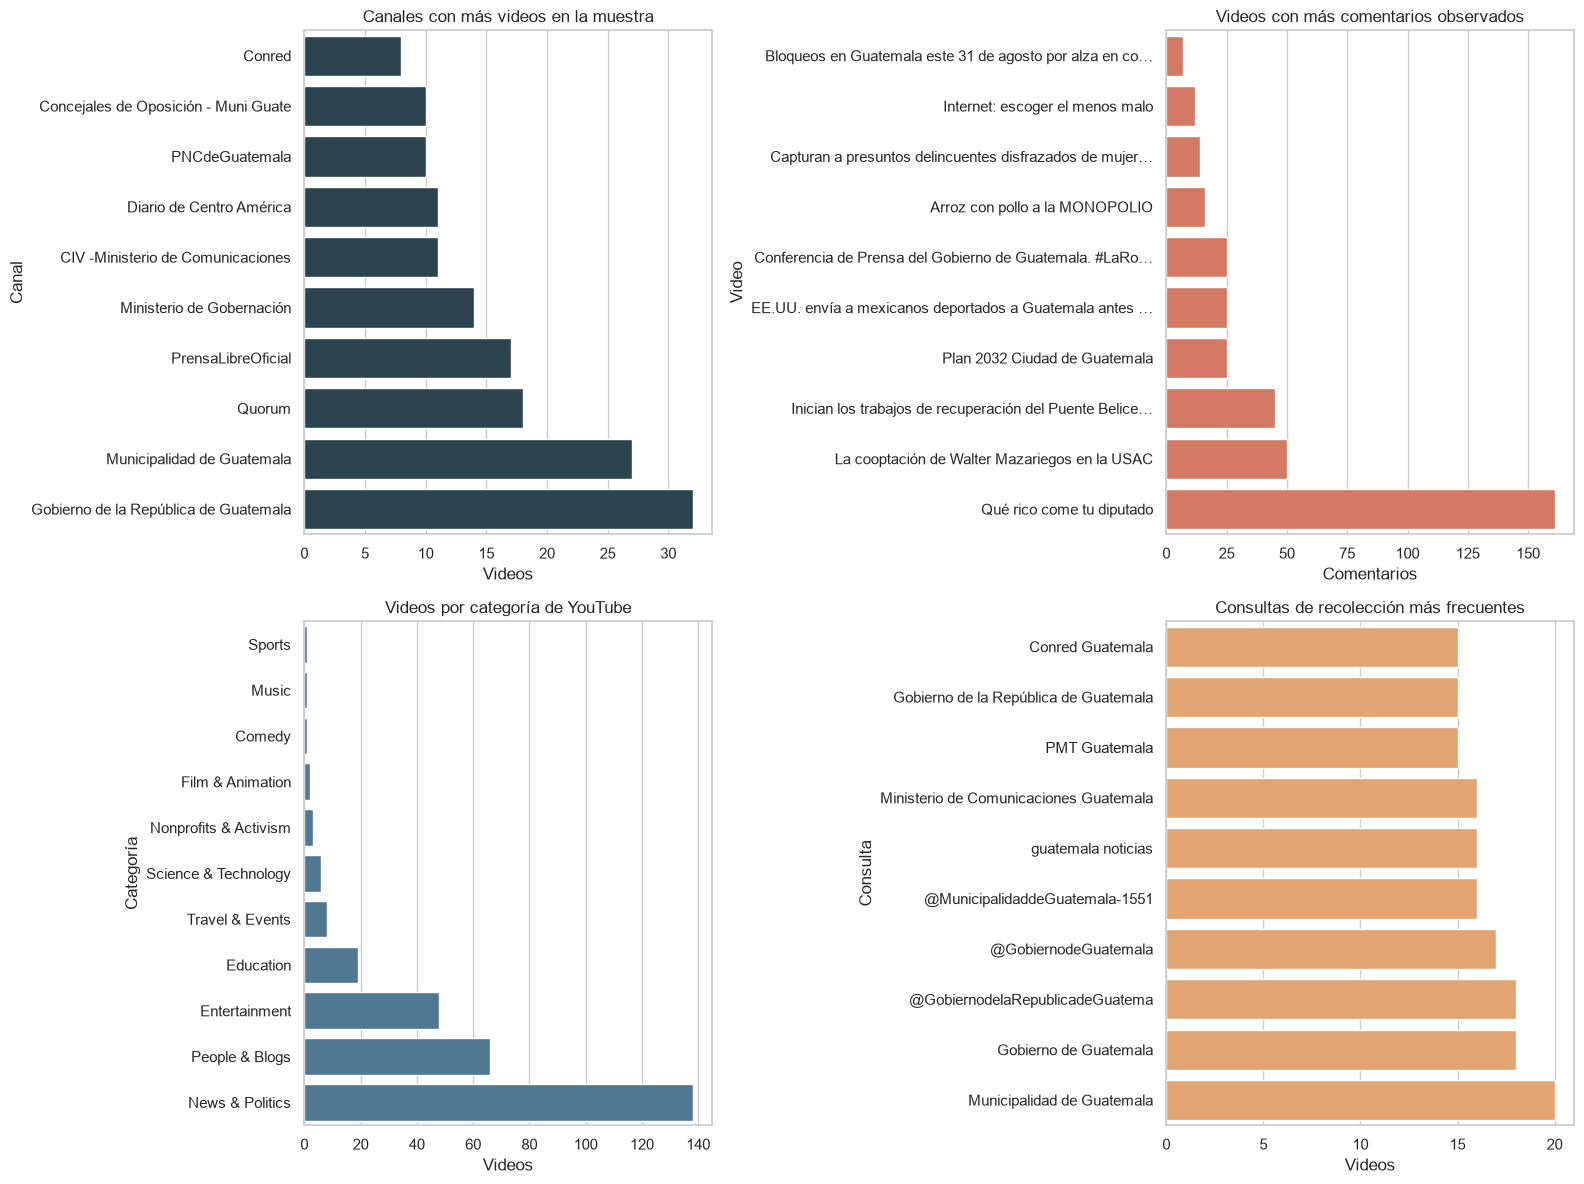

In [14]:
def shorten(value, width=55):
    value = str(value)
    return value if len(value) <= width else value[: width - 1] + "…"

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_channels_videos = videos_by_channel.head(10).sort_values("videos")
sns.barplot(data=top_channels_videos, x="videos", y="channel_name", color=COLORS["accent"], ax=axes[0, 0])
axes[0, 0].set_title("Canales con más videos en la muestra")
axes[0, 0].set(xlabel="Videos", ylabel="Canal")

top_videos_comments = comments_by_video.head(10).copy().sort_values("comentarios")
top_videos_comments["etiqueta"] = top_videos_comments["title"].map(shorten)
sns.barplot(data=top_videos_comments, x="comentarios", y="etiqueta", color=COLORS["video"], ax=axes[0, 1])
axes[0, 1].set_title("Videos con más comentarios observados")
axes[0, 1].set(xlabel="Comentarios", ylabel="Video")

category_counts = videos["category"].value_counts().rename_axis("category").reset_index(name="videos")
sns.barplot(data=category_counts.sort_values("videos"), x="videos", y="category", color="#457B9D", ax=axes[1, 0])
axes[1, 0].set_title("Videos por categoría de YouTube")
axes[1, 0].set(xlabel="Videos", ylabel="Categoría")

query_counts = videos["source_query"].value_counts().head(10).rename_axis("source_query").reset_index(name="videos")
sns.barplot(data=query_counts.sort_values("videos"), x="videos", y="source_query", color="#F4A261", ax=axes[1, 1])
axes[1, 1].set_title("Consultas de recolección más frecuentes")
axes[1, 1].set(xlabel="Videos", ylabel="Consulta")

plt.tight_layout()
plt.show()

Las categorías y consultas describen la composición de esta muestra. Una categoría amplia como *News & Politics* o una consulta frecuente no demuestra que ese tema domine YouTube en general: refleja, en parte, cómo se recolectaron los datos.

,count,mean,std,min,25%,50%,75%,90%,95%,max
visualizaciones,293.0,60430.09,515798.31,2.0,215.0,1175.0,7465.0,51318.8,130467.0,8190449.0
respuestas,406.0,0.13,0.58,0.0,0.0,0.0,0.0,0.0,1.0,7.0
me_gusta_conocidos,217.0,10.71,41.34,1.0,1.0,2.0,4.0,13.4,31.8,405.0


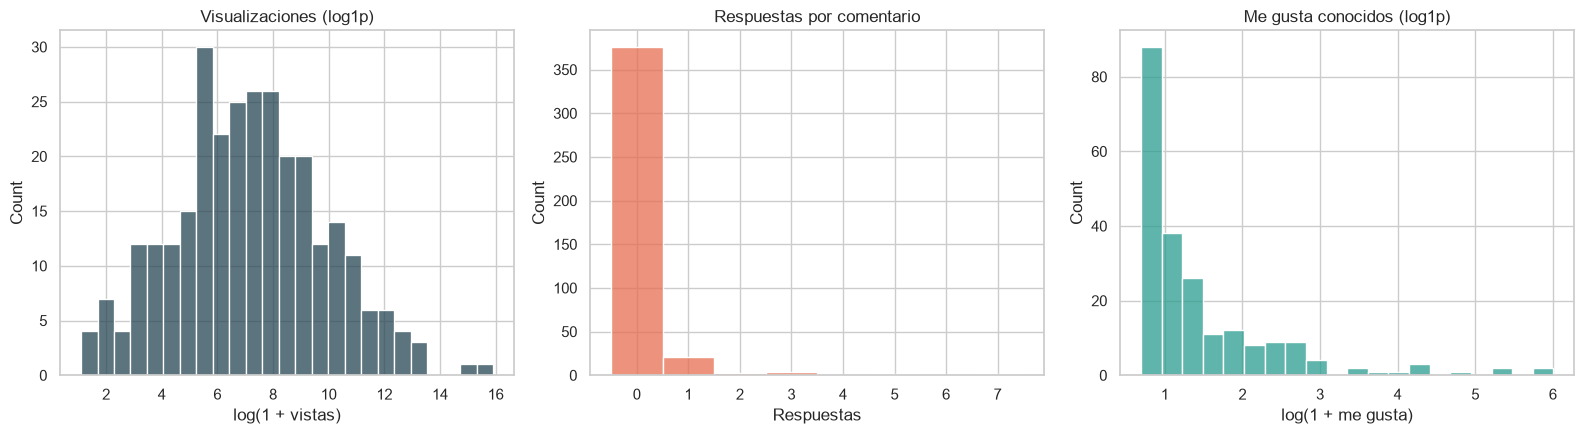

In [15]:
numeric_summary = pd.concat([
    videos["view_count"].rename("visualizaciones").describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]),
    comments["reply_count"].rename("respuestas").describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]),
    comments["like_count"].rename("me_gusta_conocidos").describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]),
], axis=1).T
display(numeric_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(np.log1p(videos["view_count"].dropna()), bins=25, color=COLORS["accent"], ax=axes[0])
axes[0].set(title="Visualizaciones (log1p)", xlabel="log(1 + vistas)")
sns.histplot(comments["reply_count"].dropna(), discrete=True, color=COLORS["video"], ax=axes[1])
axes[1].set(title="Respuestas por comentario", xlabel="Respuestas")
sns.histplot(np.log1p(comments["like_count"].dropna()), bins=20, color=COLORS["author"], ax=axes[2])
axes[2].set(title="Me gusta conocidos (log1p)", xlabel="log(1 + me gusta)")
plt.tight_layout()
plt.show()

### Hashtags, palabras y bigramas

Las palabras y bigramas se cuentan en comentarios después de la limpieza conservadora. Los hashtags se reportan por separado para comentarios y para metadatos de videos (título + descripción). Una nube de palabras no se usa porque no sustituye los conteos comparables.

In [16]:
comment_hashtags = list_frequency_table(comments["hashtags"], "hashtag", top_n=15)
video_text = videos["title"].fillna("").astype(str) + " " + videos["description"].fillna("").astype(str)
video_hashtags_json = video_text.map(lambda value: clean_text_record(value)["hashtags"])
video_hashtags = list_frequency_table(video_hashtags_json, "hashtag", top_n=15)
top_words = frequency_table(comments["texto_limpio"], ngram=1, top_n=15)
top_bigrams = frequency_table(comments["texto_limpio"], ngram=2, top_n=15)

display(Markdown("**Hashtags en comentarios**")); display(comment_hashtags)
display(Markdown("**Hashtags en títulos y descripciones de videos**")); display(video_hashtags)
display(Markdown("**Palabras en comentarios**")); display(top_words)
display(Markdown("**Bigramas en comentarios**")); display(top_bigrams)

**Hashtags en comentarios**

,hashtag,frecuencia
0,ineptobran,1


**Hashtags en títulos y descripciones de videos**

,hashtag,frecuencia
0,guatemala,48
1,larondagt,29
2,noticias,14
3,envivodca,12
4,nacionales,7
5,like,7
6,comenta,7
7,comparte,7
8,siguenos,7
9,protegeryservir,6


**Palabras en comentarios**

,palabra,frecuencia
0,no,196
1,pueblo,56
2,guatemala,52
3,dinero,34
4,presidente,32
5,país,31
6,trabajo,30
7,diputados,28
8,corruptos,24
9,diputado,22


**Bigramas en comentarios**

,2-grama,frecuencia
0,presidente bernardo,9
1,bernardo arevalo,8
2,diputados no,6
3,ciudad guatemala,6
4,cosas no,5
5,nery rodas,5
6,bla bla,5
7,pacto corruptos,5
8,viva guatemala,4
9,busquen trabajo,4


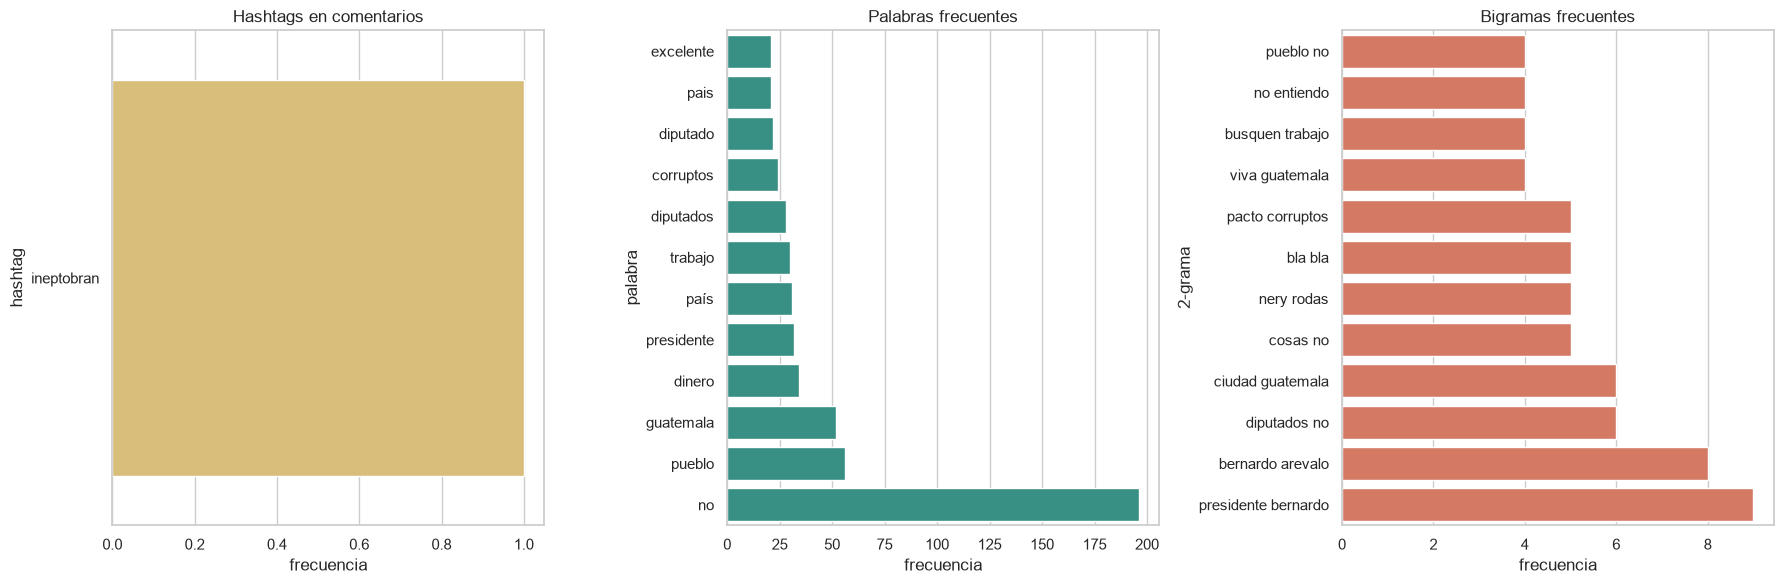

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_hashtags = comment_hashtags.head(12).sort_values("frecuencia")
if len(plot_hashtags):
    sns.barplot(data=plot_hashtags, x="frecuencia", y="hashtag", color="#E9C46A", ax=axes[0])
axes[0].set_title("Hashtags en comentarios")

plot_words = top_words.head(12).sort_values("frecuencia")
sns.barplot(data=plot_words, x="frecuencia", y="palabra", color=COLORS["author"], ax=axes[1])
axes[1].set_title("Palabras frecuentes")

plot_bigrams = top_bigrams.head(12).sort_values("frecuencia")
sns.barplot(data=plot_bigrams, x="frecuencia", y="2-grama", color=COLORS["video"], ax=axes[2])
axes[2].set_title("Bigramas frecuentes")

plt.tight_layout()
plt.show()

## 3.2 Concentración de la participación

Se calcula qué porcentaje de los comentarios corresponde a los elementos más activos. Para las curvas acumuladas se incluyen los videos y canales sin comentarios observados, porque excluirlos ocultaría parte de la concentración.

,entidad,cantidad_entidades,participación_top_1,participación_top_5,participación_top_10,participación_top_20pct_entidades
0,videos,293,39.7%,75.4%,93.6%,100.0%
1,canales,97,63.1%,96.1%,100.0%,100.0%


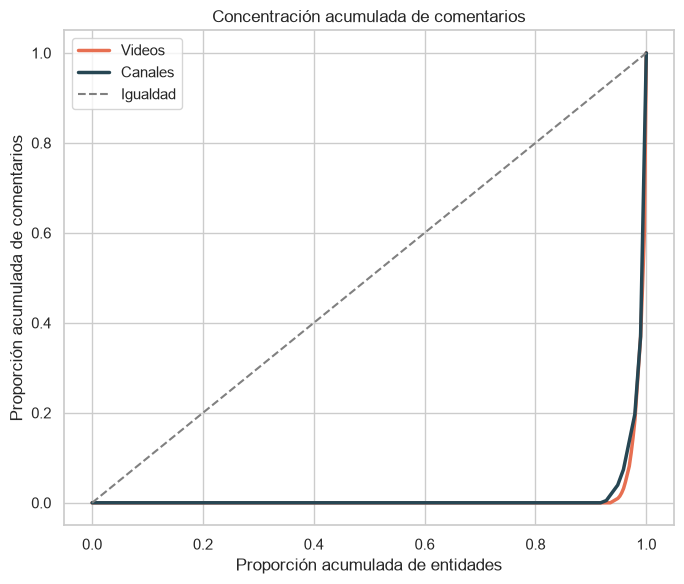

In [18]:
def concentration_row(entity, counts):
    counts = pd.Series(counts).sort_values(ascending=False)
    total = counts.sum()
    top_20_percent = max(1, int(np.ceil(0.20 * len(counts))))
    return {
        "entidad": entity, "cantidad_entidades": len(counts),
        "participación_top_1": counts.head(1).sum() / total,
        "participación_top_5": counts.head(5).sum() / total,
        "participación_top_10": counts.head(10).sum() / total,
        "participación_top_20pct_entidades": counts.head(top_20_percent).sum() / total,
    }

video_counts_all = videos[["video_id"]].merge(
    comments.groupby("video_id").size().rename("comentarios"),
    on="video_id", how="left",
)["comentarios"].fillna(0)
channel_counts_all = videos[["channel_id"]].drop_duplicates().merge(
    comments.groupby("channel_id").size().rename("comentarios"),
    on="channel_id", how="left",
)["comentarios"].fillna(0)

concentration = pd.DataFrame([
    concentration_row("videos", video_counts_all),
    concentration_row("canales", channel_counts_all),
])
percentage_columns = [column for column in concentration.columns if column.startswith("participación")]
display(concentration.style.format({column: "{:.1%}" for column in percentage_columns}))

def lorenz_points(values):
    values = np.sort(np.asarray(values, dtype=float))
    cumulative = np.insert(np.cumsum(values), 0, 0.0)
    cumulative = cumulative / cumulative[-1]
    population = np.linspace(0, 1, len(cumulative))
    return population, cumulative

fig, ax = plt.subplots(figsize=(7, 6))
for label, counts, color in [
    ("Videos", video_counts_all, COLORS["video"]),
    ("Canales", channel_counts_all, COLORS["accent"]),
]:
    x, y = lorenz_points(counts)
    ax.plot(x, y, label=label, linewidth=2.5, color=color)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Igualdad")
ax.set(title="Concentración acumulada de comentarios",
       xlabel="Proporción acumulada de entidades",
       ylabel="Proporción acumulada de comentarios")
ax.legend()
plt.tight_layout()
plt.show()

## 3.3 Popularidad y participación

Las visualizaciones miden exposición acumulada observada; los comentarios disponibles miden participación dentro de una recolección parcial. Se usa correlación de Spearman porque ambas variables son muy asimétricas y no se supone una relación lineal.

,rho_spearman,p_value,videos_comparables
0,0.0803,0.1703,293


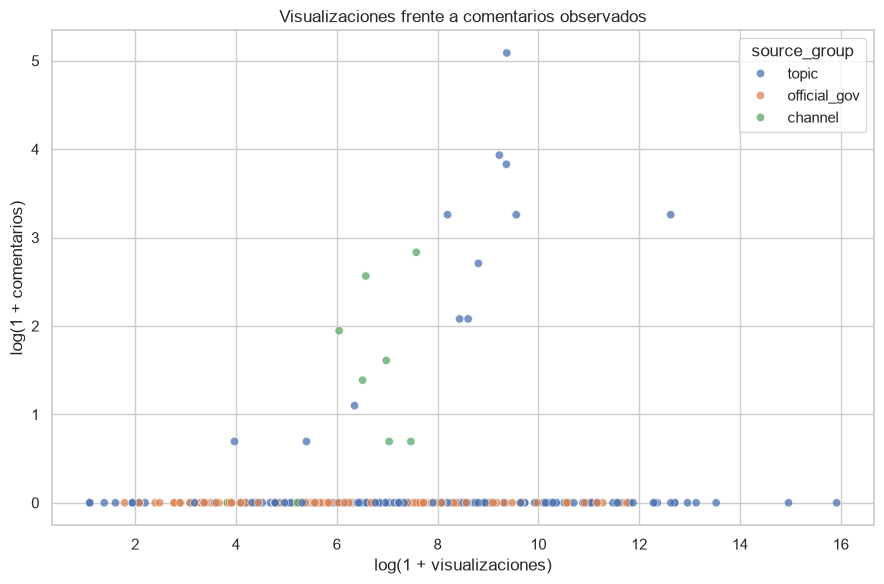

In [19]:
video_activity = videos[["video_id", "title", "channel_name", "source_group", "view_count"]].merge(
    comments.groupby("video_id").agg(
        comentarios=("comment_id", "size"), autores_unicos=("author_channel_id", "nunique"),
    ), on="video_id", how="left",
)
video_activity[["comentarios", "autores_unicos"]] = video_activity[["comentarios", "autores_unicos"]].fillna(0).astype(int)
correlation_data = video_activity.dropna(subset=["view_count"])
rho, p_value = spearmanr(correlation_data["view_count"], correlation_data["comentarios"])

display(pd.DataFrame([{
    "rho_spearman": rho, "p_value": p_value, "videos_comparables": len(correlation_data),
}]).round(4))

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=correlation_data,
    x=np.log1p(correlation_data["view_count"].astype(float)),
    y=np.log1p(correlation_data["comentarios"].astype(float)),
    hue="source_group", alpha=0.75, ax=ax,
)
ax.set(title="Visualizaciones frente a comentarios observados",
       xlabel="log(1 + visualizaciones)", ylabel="log(1 + comentarios)")
plt.tight_layout()
plt.show()

La correlación describe asociación, no causalidad. Además, los conteos no tienen la misma cobertura temporal: un video puede acumular vistas durante años mientras que el archivo contiene solo una selección de comentarios principales.

## 3.4 Visualizaciones pertinentes

Las visualizaciones anteriores comparan composición, distribuciones, frecuencias, concentración y asociación. Se conservaron escalas lineales para conteos pequeños y se usó log1p únicamente en variables de cola larga. Ninguna gráfica elimina observaciones; los ceros de comentarios permanecen visibles en la concentración y en la comparación con visualizaciones.

## 3.5 Respuestas a las preguntas obligatorias

Este primer resumen responde con la evidencia disponible al terminar el análisis exploratorio. Las respuestas sobre comunidades y sentimiento se actualizan con las métricas formales en la sección 10.4.

In [20]:
author_activity = (
    comments.groupby("author_channel_id")
    .agg(etiqueta=("author_handle", lambda s: s.dropna().iloc[0] if s.notna().any() else "sin handle"),
         comentarios=("comment_id", "size"), videos_unicos=("video_id", "nunique"),
         canales_unicos=("channel_id", "nunique"))
    .reset_index()
    .sort_values(["videos_unicos", "canales_unicos", "comentarios"], ascending=False)
)
shared_audience = author_activity["videos_unicos"].gt(1)
bridge_candidates = author_activity.head(3)["etiqueta"].astype(str).tolist()
top_video = comments_by_video.iloc[0]
top_channel = comments_by_channel.iloc[0]
theme_terms = ", ".join(top_words.head(5)["palabra"].astype(str))

mandatory_answers = pd.DataFrame([
    {"pregunta": "¿Qué videos y canales concentran mayor participación?",
     "respuesta_preliminar": f"El video con más comentarios observados es '{top_video['title']}' ({int(top_video['comentarios'])}); el canal con mayor conteo observado es '{top_channel['channel_name']}' ({int(top_channel['comentarios'])})."},
    {"pregunta": "¿Existen audiencias compartidas?",
     "respuesta_preliminar": f"Sí en la muestra: {int(shared_audience.sum())} de {len(author_activity)} autores ({shared_audience.mean():.1%}) comentaron más de un video. Esto es coparticipación, no amistad."},
    {"pregunta": "¿Qué autores funcionan como puentes?",
     "respuesta_preliminar": "Por diversidad de videos/canales, los primeros candidatos son " + ", ".join(bridge_candidates) + ". La intermediación formal se calculará en el ejercicio 8."},
    {"pregunta": "¿Qué temas y sentimientos caracterizan comunidades?",
     "respuesta_preliminar": f"En el corpus limpio destacan términos como {theme_terms}. Aún no se asignan temas a comunidades ni sentimientos: hacerlo antes de los ejercicios 7 y 9 sería especulativo."},
    {"pregunta": "¿Visibilidad y participación coinciden?",
     "respuesta_preliminar": f"La asociación de Spearman entre vistas y comentarios recolectados es rho={rho:.3f}. No implica equivalencia porque ambos conteos tienen coberturas distintas."},
    {"pregunta": "¿Qué limita las conclusiones?",
     "respuesta_preliminar": "La selección por consultas/canales, la cobertura parcial de comentarios, fechas relativas, conteos capturados en momentos distintos y la ausencia de relaciones explícitas entre autores."},
])
display(mandatory_answers)

,pregunta,respuesta_preliminar
0,¿Qué videos y canales concentran mayor participación?,El video con más comentarios observados es 'Qué rico come tu diputado' (161); el canal con mayor conteo observado es...
1,¿Existen audiencias compartidas?,"Sí en la muestra: 9 de 332 autores (2.7%) comentaron más de un video. Esto es coparticipación, no amistad."
2,¿Qué autores funcionan como puentes?,"Por diversidad de videos/canales, los primeros candidatos son /@hashojea7348, /@inge_vergueta, /@virgiliogarcia3039...."
3,¿Qué temas y sentimientos caracterizan comunidades?,"En el corpus limpio destacan términos como no, pueblo, guatemala, dinero, presidente. Aún no se asignan temas a comu..."
4,¿Visibilidad y participación coinciden?,La asociación de Spearman entre vistas y comentarios recolectados es rho=0.080. No implica equivalencia porque ambos...
5,¿Qué limita las conclusiones?,"La selección por consultas/canales, la cobertura parcial de comentarios, fechas relativas, conteos capturados en mom..."


## 3.6 Tres preguntas adicionales

Las respuestas se calculan directamente del corpus y ayudan a distinguir actividad recurrente, cobertura y recepción de respuestas.

In [21]:
videos_without_comments = int(video_activity["comentarios"].eq(0).sum())
authors_one_comment = int(author_activity["comentarios"].eq(1).sum())
comments_with_replies = int(comments["reply_count"].gt(0).sum())

additional_questions = pd.DataFrame([
    {"pregunta": "¿La mayoría de autores participa una sola vez?",
     "evidencia": f"{authors_one_comment} de {len(author_activity)} autores ({authors_one_comment / len(author_activity):.1%}) tienen exactamente un comentario observado."},
    {"pregunta": "¿Cuántos videos quedaron sin comentarios en el archivo?",
     "evidencia": f"{videos_without_comments} de {len(video_activity)} videos ({videos_without_comments / len(video_activity):.1%}) no tienen comentarios recolectados; esto no significa cero comentarios en YouTube."},
    {"pregunta": "¿Qué tan frecuente es recibir al menos una respuesta?",
     "evidencia": f"{comments_with_replies} de {len(comments)} comentarios ({comments_with_replies / len(comments):.1%}) tienen reply_count > 0; acumulan {int(comments['reply_count'].sum())} respuestas no identificadas."},
])
display(additional_questions)

,pregunta,evidencia
0,¿La mayoría de autores participa una sola vez?,286 de 332 autores (86.1%) tienen exactamente un comentario observado.
1,¿Cuántos videos quedaron sin comentarios en el archivo?,274 de 293 videos (93.5%) no tienen comentarios recolectados; esto no significa cero comentarios en YouTube.
2,¿Qué tan frecuente es recibir al menos una respuesta?,30 de 406 comentarios (7.4%) tienen reply_count > 0; acumulan 51 respuestas no identificadas.


# 4. Construcción de la red bipartita autor–video

## 4.1–4.3 Definición y tablas auditables

La red es no dirigida y tiene dos tipos de nodo:

- `author`: identificado por `author_channel_id`;
- `video`: identificado por `video_id`.

Existe una arista cuando un autor publicó al menos un comentario principal en un video. Su peso es el número de comentarios observados para ese par. Los prefijos `author::` y `video::` impiden colisiones accidentales entre espacios de IDs.

In [22]:
nodes, edges = build_network_tables(comments, videos)
graph = build_bipartite_graph(nodes, edges)
save_network_tables(nodes, edges)

isolates = list(nx.isolates(graph))
network_audit = pd.DataFrame([
    {"métrica": "nodos autores", "valor": int(nodes["node_type"].eq("author").sum())},
    {"métrica": "nodos videos", "valor": int(nodes["node_type"].eq("video").sum())},
    {"métrica": "nodos totales", "valor": graph.number_of_nodes()},
    {"métrica": "aristas autor-video", "valor": graph.number_of_edges()},
    {"métrica": "suma de pesos (comentarios utilizables)", "valor": int(edges["weight"].sum())},
    {"métrica": "videos aislados en la muestra", "valor": sum(node.startswith("video::") for node in isolates)},
    {"métrica": "autores aislados", "valor": sum(node.startswith("author::") for node in isolates)},
    {"métrica": "es bipartita", "valor": nx.algorithms.bipartite.is_bipartite(graph)},
])
display(network_audit)

,métrica,valor
0,nodos autores,332
1,nodos videos,293
2,nodos totales,625
3,aristas autor-video,343
4,suma de pesos (comentarios utilizables),406
5,videos aislados en la muestra,274
6,autores aislados,0
7,es bipartita,True


In [23]:
display(Markdown("**Muestra de la tabla de nodos**")); display(nodes.head(8))
display(Markdown("**Muestra de la tabla de aristas con mayor peso**")); display(edges.sort_values(["weight", "video_title"], ascending=[False, True]).head(12))

edge_validation = pd.DataFrame([
    {"validación": "IDs de nodos únicos", "cumple": nodes["node_id"].is_unique},
    {"validación": "pesos estrictamente positivos", "cumple": edges["weight"].gt(0).all()},
    {"validación": "todos los autores existen en nodos", "cumple": set(edges["source"]).issubset(set(nodes["node_id"]))},
    {"validación": "todos los videos existen en nodos", "cumple": set(edges["target"]).issubset(set(nodes["node_id"]))},
    {"validación": "suma de pesos = comentarios utilizables", "cumple": int(edges["weight"].sum()) == len(comments.dropna(subset=["author_channel_id", "video_id"]))},
])
display(edge_validation)

**Muestra de la tabla de nodos**

,node_id,node_type,original_id,label,author_name,author_handle,channel_id,channel_name,title,category,view_count,comment_count,unique_neighbors,unique_videos,unique_channels
0,author::UC-HeUTT6_g-VoiWds2a4H-w,author,UC-HeUTT6_g-VoiWds2a4H-w,/@JorgeMunoz-gd9et,@JorgeMunoz-gd9et,/@JorgeMunoz-gd9et,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
1,author::UC-Iul5tDYH_oiAMXQH-KaaQ,author,UC-Iul5tDYH_oiAMXQH-KaaQ,/@AlbertoMancilla-p9h,@AlbertoMancilla-p9h,/@AlbertoMancilla-p9h,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
2,author::UC-QOpE7GOxlXcHZ8b7HbQKA,author,UC-QOpE7GOxlXcHZ8b7HbQKA,/@mariaalexander427,@mariaalexander427,/@mariaalexander427,NaN,<NA>,<NA>,<NA>,<NA>,2,1,1,1
3,author::UC-fiZBS5Gp1eCJd9ucgWnCg,author,UC-fiZBS5Gp1eCJd9ucgWnCg,/@Tommii.10,@Tommii.10,/@Tommii.10,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
4,author::UC-hfX8J5JPJ-dfuakzegMLA,author,UC-hfX8J5JPJ-dfuakzegMLA,/@normaleticiaorozcojuarez2418,@normaleticiaorozcojuarez2418,/@normaleticiaorozcojuarez2418,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
5,author::UC-jS_kA9w-OmpupXDx156Rg,author,UC-jS_kA9w-OmpupXDx156Rg,/@simoncreyesc7579,@simoncreyesc7579,/@simoncreyesc7579,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
6,author::UC-pNP6RMFuLg_-x7Ah_0kEA,author,UC-pNP6RMFuLg_-x7Ah_0kEA,/@almacatalan2717,@almacatalan2717,/@almacatalan2717,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1
7,author::UC094EFEmMSdwVa8NQjjYBXg,author,UC094EFEmMSdwVa8NQjjYBXg,/@CelestinoQuej-j7k,@CelestinoQuej-j7k,/@CelestinoQuej-j7k,NaN,<NA>,<NA>,<NA>,<NA>,1,1,1,1


**Muestra de la tabla de aristas con mayor peso**

,source,target,weight,author_channel_id,video_id,video_title,channel_id,channel_name
244,author::UCi2KiZq63sRq8Mfbcp-MelQ,video::OkXlHx0hx-8,6,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo
331,author::UCyJhqmMbsvjpoarBBStA2kg,video::6W4u8sGEnGM,6,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala
165,author::UCV3fr-YOixFKCZBbJP1-X4w,video::6W4u8sGEnGM,5,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala
33,author::UC5H8ASmMC9WrURmzeB4ySog,video::n8iP75gIpmw,5,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum
57,author::UC9vMq1YF-e7C-VO0SHkbUTA,video::n8iP75gIpmw,4,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum
120,author::UCNIeXbV_mEwpa412h1aqUWw,video::PjmxCj-a9Hg,3,UCNIeXbV_mEwpa412h1aqUWw,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala
226,author::UCg3eIfd7BrsLEqS0BLkftHA,video::PjmxCj-a9Hg,3,UCg3eIfd7BrsLEqS0BLkftHA,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala
25,author::UC3XTwHxygNCgjndsg-UiCQA,video::n8iP75gIpmw,3,UC3XTwHxygNCgjndsg-UiCQA,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum
46,author::UC72gBAtyb_VXQlYDcFrh6oQ,video::n8iP75gIpmw,3,UC72gBAtyb_VXQlYDcFrh6oQ,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum
85,author::UCFjudnPLoaSL1BaRuLahyHg,video::n8iP75gIpmw,3,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum


,validación,cumple
0,IDs de nodos únicos,True
1,pesos estrictamente positivos,True
2,todos los autores existen en nodos,True
3,todos los videos existen en nodos,True
4,suma de pesos = comentarios utilizables,True


## 4.4 Visualización de la red completa

Se dibujan todos los nodos y todas las aristas, incluidos los videos aislados. Solo se limitan las **etiquetas de texto** a los nodos con mayor grado para mantener legibilidad; no se filtra la estructura. El tamaño representa grado y el grosor de arista usa el peso.

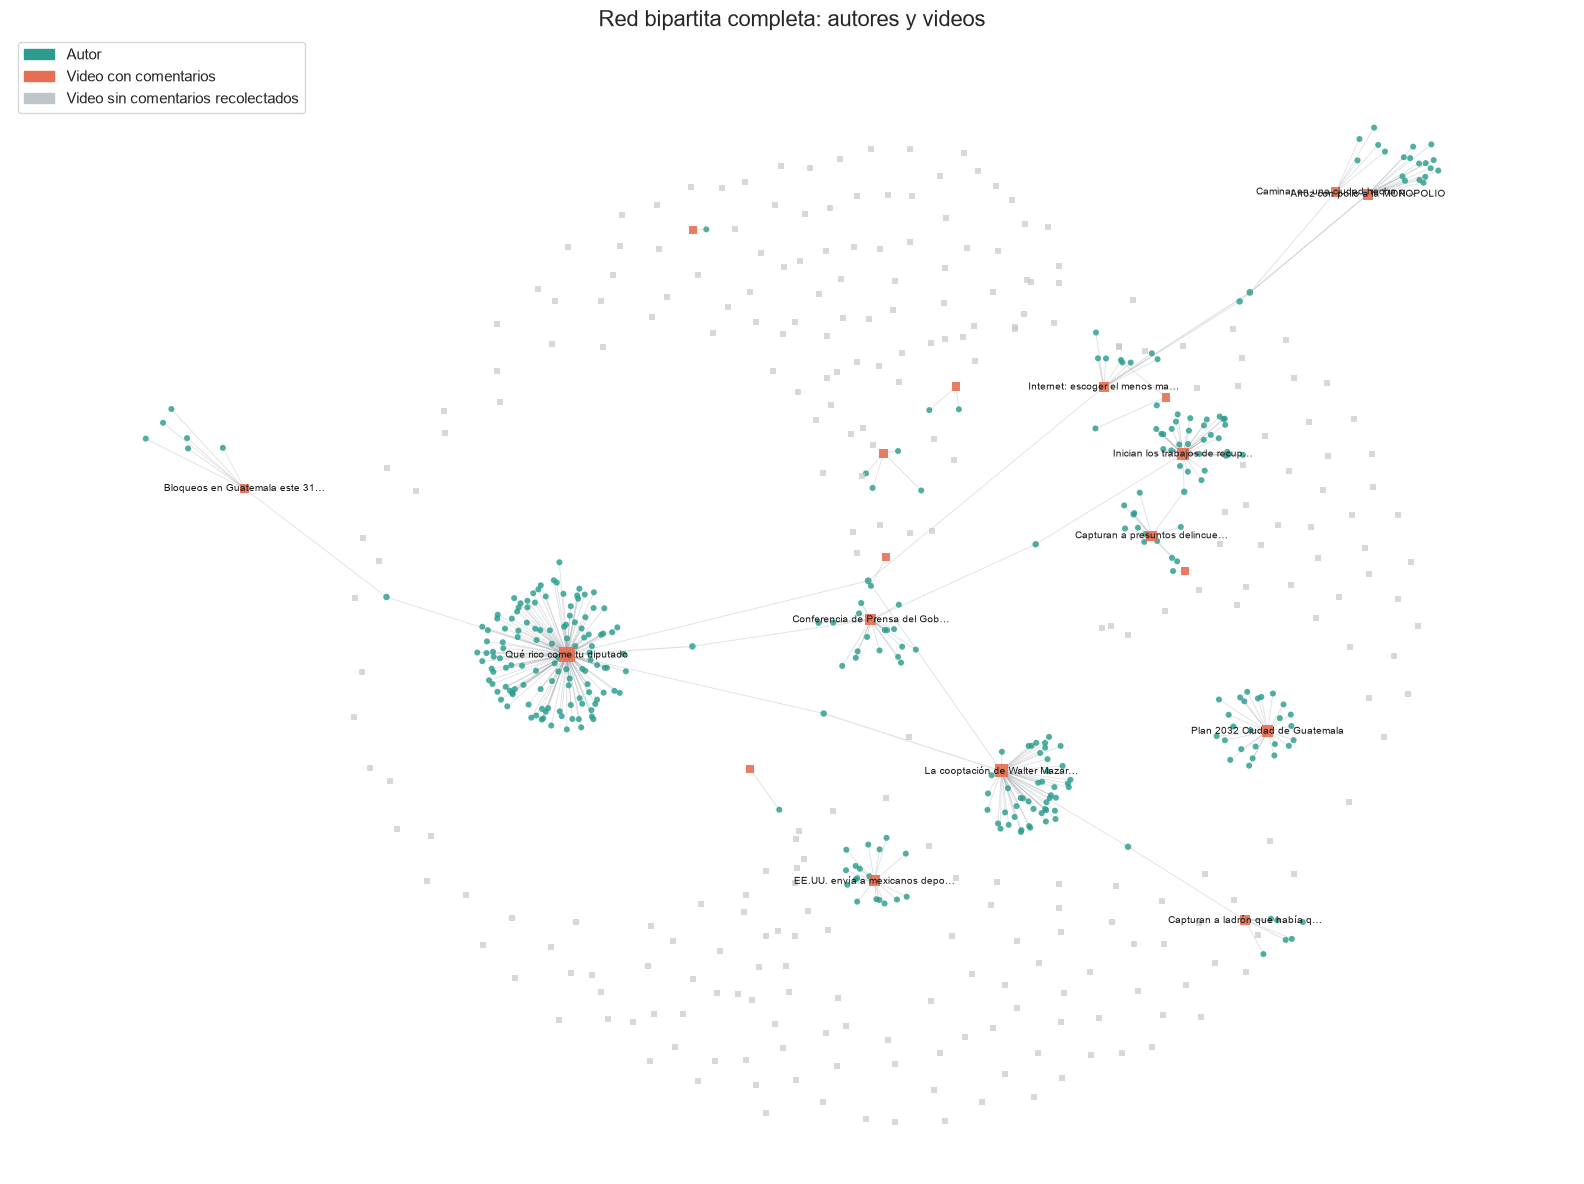

In [24]:
degrees = dict(graph.degree())
positions = nx.spring_layout(graph, seed=42, k=0.20, iterations=100, weight="weight")

author_nodes = [node for node, attrs in graph.nodes(data=True) if attrs["node_type"] == "author"]
video_nodes = [node for node, attrs in graph.nodes(data=True) if attrs["node_type"] == "video"]
isolated_videos = [node for node in video_nodes if degrees[node] == 0]
active_videos = [node for node in video_nodes if degrees[node] > 0]

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(
    graph, positions,
    width=[0.25 + 0.55 * np.log1p(graph[u][v]["weight"]) for u, v in graph.edges()],
    alpha=0.22, edge_color="#6C757D", ax=ax,
)
nx.draw_networkx_nodes(
    graph, positions, nodelist=author_nodes, node_color=COLORS["author"],
    node_size=[12 + 7 * np.sqrt(degrees[node]) for node in author_nodes],
    alpha=0.82, linewidths=0, ax=ax,
)
nx.draw_networkx_nodes(
    graph, positions, nodelist=active_videos, node_color=COLORS["video"], node_shape="s",
    node_size=[25 + 9 * np.sqrt(degrees[node]) for node in active_videos],
    alpha=0.9, linewidths=0, ax=ax,
)
nx.draw_networkx_nodes(
    graph, positions, nodelist=isolated_videos, node_color="#BFC5C9", node_shape="s",
    node_size=18, alpha=0.65, linewidths=0, ax=ax,
)

top_label_nodes = sorted(
    (node for node in graph.nodes if degrees[node] > 0),
    key=lambda node: degrees[node], reverse=True,
)[:12]
labels = {
    node: shorten(graph.nodes[node].get("label", graph.nodes[node].get("original_id", node)), 30)
    for node in top_label_nodes
}
nx.draw_networkx_labels(graph, positions, labels=labels, font_size=7, ax=ax)

ax.legend(handles=[
    Patch(color=COLORS["author"], label="Autor"),
    Patch(color=COLORS["video"], label="Video con comentarios"),
    Patch(color="#BFC5C9", label="Video sin comentarios recolectados"),
], loc="upper left")
ax.set_title("Red bipartita completa: autores y videos", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4.5 Interpretación correcta de una arista

Una arista representa únicamente que un autor publicó uno o más comentarios principales en un video dentro de los datos recolectados. El peso cuenta esos comentarios. La relación **no** demuestra amistad, conversación directa, respuesta entre usuarios, aprobación, identidad fuera de YouTube ni exposición completa al video. Dos autores todavía no están conectados entre sí en esta red; esa relación aparecerá solo como coparticipación en la proyección autor–autor del ejercicio 5.

# 5. Proyecciones de la red

## 5.1-5.2 Construcción y significado de los pesos

Se proyecta la red bipartita sin usar nombres como identificadores. En la proyección **autor-autor**, dos autores quedan conectados si comentaron al menos un mismo video y el peso cuenta **videos compartidos**. En la proyección **video-video**, dos videos quedan conectados si comparten al menos un autor y el peso cuenta **autores compartidos**.

El número de comentarios de una arista autor-video no se suma al peso proyectado: una coincidencia de vecino se cuenta una sola vez. Se conservan todos los autores y videos, incluidos los aislados.

In [25]:
author_projection, video_projection = build_projections(graph)
author_projection_edges = projection_edge_table(author_projection, "author-author")
video_projection_edges = projection_edge_table(video_projection, "video-video")

projection_audit = pd.DataFrame([
    {"proyección": "autor-autor", "nodos": author_projection.number_of_nodes(),
     "aristas": author_projection.number_of_edges(),
     "suma_pesos": int(author_projection_edges["weight"].sum()),
     "peso_máximo": int(author_projection_edges["weight"].max()),
     "aislados": nx.number_of_isolates(author_projection)},
    {"proyección": "video-video", "nodos": video_projection.number_of_nodes(),
     "aristas": video_projection.number_of_edges(),
     "suma_pesos": int(video_projection_edges["weight"].sum()),
     "peso_máximo": int(video_projection_edges["weight"].max()),
     "aislados": nx.number_of_isolates(video_projection)},
])
display(projection_audit)

def labeled_projection_edges(projection, top_n=10):
    rows = []
    for source, target, data in projection.edges(data=True):
        rows.append({
            "origen": projection.nodes[source].get("label", source),
            "destino": projection.nodes[target].get("label", target),
            "peso": data["weight"],
        })
    return pd.DataFrame(rows).sort_values(["peso", "origen"], ascending=[False, True]).head(top_n)

display(Markdown("**Pares de autores con más videos compartidos**"))
display(labeled_projection_edges(author_projection))
display(Markdown("**Pares de videos con más autores compartidos**"))
display(labeled_projection_edges(video_projection))

,proyección,nodos,aristas,suma_pesos,peso_máximo,aislados
0,autor-autor,332,10732,10734,2,4
1,video-video,293,11,13,2,283


**Pares de autores con más videos compartidos**

,origen,destino,peso
9244,/@Alejandro00710,/@hashojea7348,2
10424,/@inge_vergueta,/@Jel.Awesh.M,2
10147,/@11223344An,/@marioramirez299,1
10148,/@11223344An,/@hashojea7348,1
10149,/@11223344An,/@angelmartinez9523,1
10014,/@2jose82,/@inge_vergueta,1
10015,/@2jose82,/@hashojea7348,1
10016,/@2jose82,/@cmorera21,1
8030,/@3762Jorge,/@11223344An,1
8031,/@3762Jorge,/@miguelbran1268,1


**Pares de videos con más autores compartidos**

,origen,destino,peso
10,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO,2
7,La cooptación de Walter Mazariegos en la USAC,Qué rico come tu diputado,2
5,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales,Qué rico come tu diputado,1
3,Caminar en una ciudad hecha para carros,Arroz con pollo a la MONOPOLIO,1
4,Caminar en una ciudad hecha para carros,Internet: escoger el menos malo,1
6,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalhuleu,La cooptación de Walter Mazariegos en la USAC,1
0,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Inician los trabajos de recuperación del Puente Belice II.,1
2,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Qué rico come tu diputado,1
1,Inician los trabajos de recuperación del Puente Belice II.,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,1
8,La cooptación de Walter Mazariegos en la USAC,Internet: escoger el menos malo,1


## 5.3-5.4 Comparación y visualización

La proyección autor-autor representa **coparticipación observable en contenidos**; no amistad ni conversación directa. La proyección video-video representa **solapamiento de la audiencia comentarista recolectada**. Una clique grande de autores puede surgir mecánicamente cuando muchas personas comentan el mismo video, aunque cada una haya participado una sola vez.

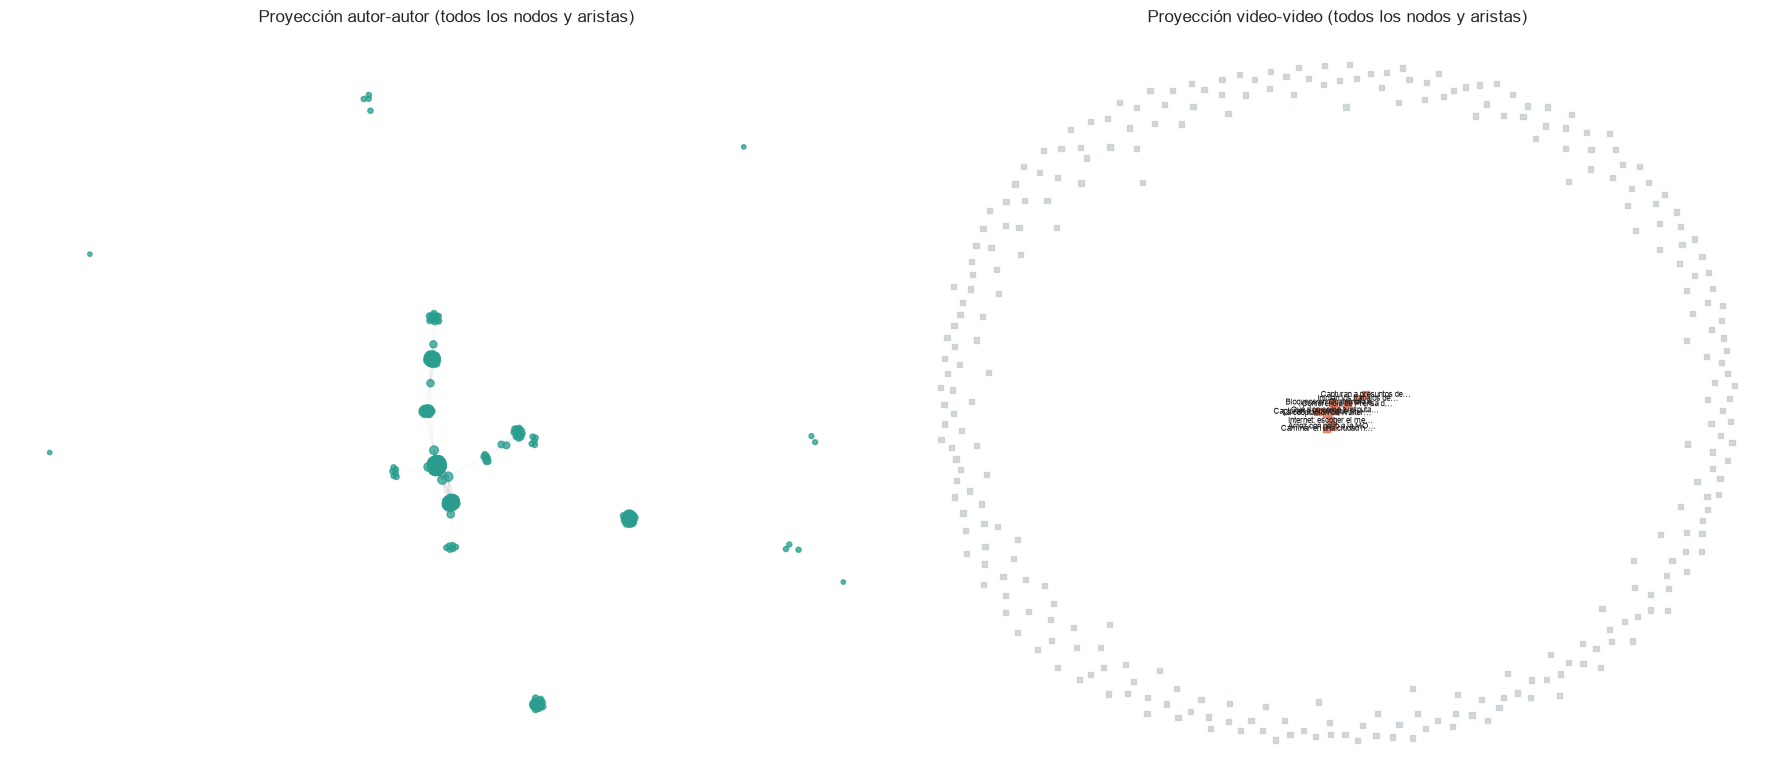

La proyección de autores contiene **10,732 aristas**, mientras la de videos solo contiene **11**. La primera cifra está dominada por grupos de autores que coincidieron en videos muy comentados; la segunda muestra que muy pocos autores reaparecieron en más de un video.

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

author_pos = nx.spring_layout(author_projection, seed=42, weight="weight", iterations=60)
author_degrees = dict(author_projection.degree())
nx.draw_networkx_edges(author_projection, author_pos, ax=axes[0], alpha=0.035,
                       width=0.25, edge_color="#718096")
nx.draw_networkx_nodes(author_projection, author_pos, ax=axes[0],
                       node_size=[10 + 2.5 * np.sqrt(author_degrees[n]) for n in author_projection],
                       node_color=COLORS["author"], alpha=0.75)
axes[0].set_title("Proyección autor-autor (todos los nodos y aristas)")
axes[0].axis("off")

video_pos = nx.spring_layout(video_projection, seed=42, weight="weight", iterations=60)
video_degrees = dict(video_projection.degree())
nx.draw_networkx_edges(video_projection, video_pos, ax=axes[1], alpha=0.40,
                       width=[0.6 + 0.7 * video_projection[u][v]["weight"] for u, v in video_projection.edges()],
                       edge_color="#718096")
nx.draw_networkx_nodes(video_projection, video_pos, ax=axes[1], node_shape="s",
                       node_size=[14 + 8 * np.sqrt(video_degrees[n]) for n in video_projection],
                       node_color=[COLORS["video"] if video_degrees[n] else "#C7CDD1" for n in video_projection],
                       alpha=0.80)
active_video_labels = {
    n: shorten(video_projection.nodes[n].get("label", n), 24)
    for n, degree in video_projection.degree() if degree > 0
}
nx.draw_networkx_labels(video_projection, video_pos, labels=active_video_labels,
                        font_size=6, ax=axes[1])
axes[1].set_title("Proyección video-video (todos los nodos y aristas)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

display(Markdown(
    f"La proyección de autores contiene **{author_projection.number_of_edges():,} aristas**, "
    f"mientras la de videos solo contiene **{video_projection.number_of_edges():,}**. "
    "La primera cifra está dominada por grupos de autores que coincidieron en videos muy comentados; "
    "la segunda muestra que muy pocos autores reaparecieron en más de un video."
))

# 6. Topología y fragmentación

## 6.1-6.2 Métricas estructurales

Se reportan las tres redes completas. La **cohesión** se operacionaliza mediante conectividad de nodos: el mínimo número de nodos cuya eliminación desconecta la red. En una red ya desconectada la conectividad global es 0, por lo que también se calcula sobre la componente más grande. La **transitividad** es la proporción global de triadas cerradas; en una red bipartita es 0 por construcción porque no puede contener triángulos.

,network,nodes,edges,density,mean_degree,median_degree,p90_degree,max_degree,isolates,leaves,components,largest_component_nodes,largest_component_share,node_connectivity,largest_component_node_connectivity,transitivity,articulation_points
0,bipartita,625,343,0.0018,1.0976,1.0,1.0,128,274,327,284,286,0.4576,0,1,0.0000,22
1,autor-autor,332,10732,0.1953,64.6506,48.0,127.0,183,4,2,10,276,0.8313,0,1,0.9840,7
2,video-video,293,11,0.0003,0.0751,0.0,0.0,4,283,3,284,10,0.0341,0,1,0.3158,5


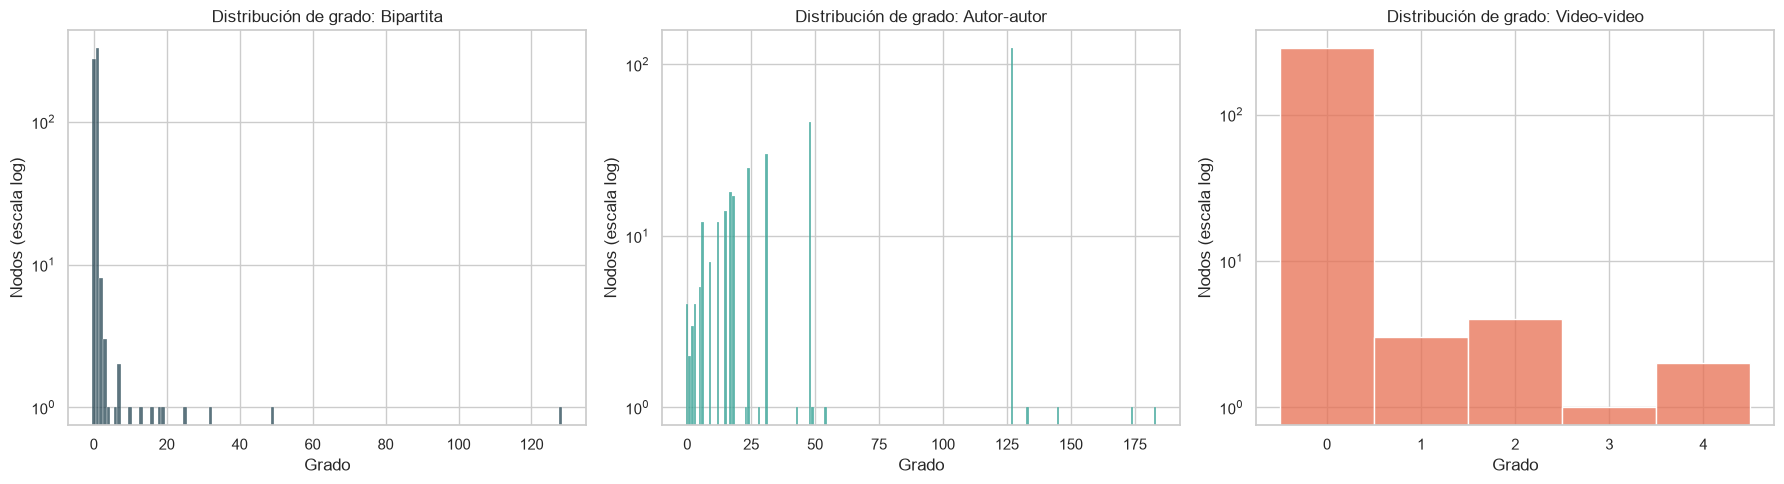

In [27]:
network_metrics = pd.DataFrame([
    network_summary(graph, "bipartita"),
    network_summary(author_projection, "autor-autor"),
    network_summary(video_projection, "video-video"),
])
degree_distributions = pd.concat([
    degree_distribution(graph, "bipartita"),
    degree_distribution(author_projection, "autor-autor"),
    degree_distribution(video_projection, "video-video"),
], ignore_index=True)

metric_columns = [
    "network", "nodes", "edges", "density", "mean_degree", "median_degree",
    "p90_degree", "max_degree", "isolates", "leaves", "components",
    "largest_component_nodes", "largest_component_share", "node_connectivity",
    "largest_component_node_connectivity", "transitivity", "articulation_points",
]
display(network_metrics[metric_columns].round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, current_graph), color in zip(
    axes,
    [("Bipartita", graph), ("Autor-autor", author_projection), ("Video-video", video_projection)],
    [COLORS["accent"], COLORS["author"], COLORS["video"]],
):
    sns.histplot([degree for _, degree in current_graph.degree()], discrete=True,
                 color=color, ax=ax)
    ax.set_yscale("log")
    ax.set_title(f"Distribución de grado: {name}")
    ax.set_xlabel("Grado")
    ax.set_ylabel("Nodos (escala log)")
plt.tight_layout()
plt.show()

## 6.3 Periferia, aislamiento y componentes

Un video aislado en la red bipartita solo significa que **no aparece ningún comentario recolectado** para él. Un nodo aislado en una proyección puede tener comentarios y aun así no compartir vecinos con otro nodo. Ninguno de estos casos prueba ausencia de audiencia o interacción en YouTube.

In [28]:
bipartite_isolates = set(nx.isolates(graph))
projection_isolated_videos = set(nx.isolates(video_projection))
active_but_unshared_videos = [
    n for n in projection_isolated_videos if graph.degree(n) > 0
]
peripheral_summary = pd.DataFrame([
    {"grupo": "autores aislados en bipartita", "cantidad": sum(n.startswith("author::") for n in bipartite_isolates)},
    {"grupo": "videos sin comentarios recolectados", "cantidad": sum(n.startswith("video::") for n in bipartite_isolates)},
    {"grupo": "autores sin coautores en proyección", "cantidad": nx.number_of_isolates(author_projection)},
    {"grupo": "videos aislados en proyección", "cantidad": nx.number_of_isolates(video_projection)},
    {"grupo": "videos comentados pero sin audiencia compartida", "cantidad": len(active_but_unshared_videos)},
    {"grupo": "hojas en bipartita (grado 1)", "cantidad": sum(1 for _, d in graph.degree() if d == 1)},
])
display(peripheral_summary)

component_rows = []
for name, current_graph in [("bipartita", graph), ("autor-autor", author_projection), ("video-video", video_projection)]:
    sizes = sorted((len(c) for c in nx.connected_components(current_graph)), reverse=True)
    component_rows.append({
        "red": name, "componentes": len(sizes),
        "cinco_mayores": ", ".join(map(str, sizes[:5])),
        "componentes_unitarias": sum(size == 1 for size in sizes),
    })
display(pd.DataFrame(component_rows))

,grupo,cantidad
0,autores aislados en bipartita,0
1,videos sin comentarios recolectados,274
2,autores sin coautores en proyección,4
3,videos aislados en proyección,283
4,videos comentados pero sin audiencia compartida,9
5,hojas en bipartita (grado 1),327


,red,componentes,cinco_mayores,componentes_unitarias
0,bipartita,284,"286, 26, 19, 5, 4",274
1,autor-autor,10,"276, 25, 18, 4, 3",4
2,video-video,284,"10, 1, 1, 1, 1",283


## 6.4 Interpretación estructural

In [29]:
bip = network_metrics.set_index("network").loc["bipartita"]
auth = network_metrics.set_index("network").loc["autor-autor"]
vid = network_metrics.set_index("network").loc["video-video"]
display(Markdown(f"""
- La red bipartita tiene **{int(bip['components'])} componentes** y su componente mayor reúne **{int(bip['largest_component_nodes'])} nodos ({bip['largest_component_share']:.1%})**. Su conectividad global es 0 por la fragmentación; incluso la componente mayor tiene conectividad {int(bip['largest_component_node_connectivity'])}, de modo que un solo nodo bien ubicado puede separarla.
- La mediana de grado bipartita es **{bip['median_degree']:.0f}**, pero el máximo es **{int(bip['max_degree'])}**: la mayoría tiene pocos vecinos y unos pocos nodos concentran la participación.
- La proyección autor-autor alcanza transitividad **{auth['transitivity']:.3f}**. No se interpreta como cohesión social: compartir un video muy comentado cierra automáticamente muchos triángulos.
- La proyección video-video tiene **{int(vid['isolates'])} aislados** y su componente mayor solo reúne **{int(vid['largest_component_nodes'])} videos**. La evidencia de circulación de autores entre contenidos es escasa.
- Se detectan **{int(bip['articulation_points'])} puntos de articulación** en la red bipartita; se identifican por tipo en el ejercicio 8.
"""))


- La red bipartita tiene **284 componentes** y su componente mayor reúne **286 nodos (45.8%)**. Su conectividad global es 0 por la fragmentación; incluso la componente mayor tiene conectividad 1, de modo que un solo nodo bien ubicado puede separarla.
- La mediana de grado bipartita es **1**, pero el máximo es **128**: la mayoría tiene pocos vecinos y unos pocos nodos concentran la participación.
- La proyección autor-autor alcanza transitividad **0.984**. No se interpreta como cohesión social: compartir un video muy comentado cierra automáticamente muchos triángulos.
- La proyección video-video tiene **283 aislados** y su componente mayor solo reúne **10 videos**. La evidencia de circulación de autores entre contenidos es escasa.
- Se detectan **22 puntos de articulación** en la red bipartita; se identifican por tipo en el ejercicio 8.


# 7. Comunidades

## 7.1-7.3 Red seleccionada, algoritmo y calidad

Se elige la proyección **video-video activa** porque agrupa contenidos mediante audiencias comentaristas compartidas, lo que responde directamente a la pregunta sobre comunidades de consumo. Se excluyen del ajuste los videos con grado 0: Louvain los devolvería como comunidades unitarias sin evidencia de relación.

Se usa **Louvain ponderado** con semilla 42. El algoritmo maximiza modularidad frente a un modelo nulo que conserva grados; un peso mayor (más autores compartidos) aporta más a la unión. Louvain es heurístico y puede cambiar con la semilla o la resolución. Además, las comunidades observadas dependen de la muestra, no son grupos sociales verificados.

In [30]:
video_membership, video_communities, video_modularity, active_video_graph = detect_video_communities(
    video_projection, seed=42
)
community_sizes = (
    video_membership.groupby("community_id")
    .agg(videos=("node_id", "size"))
    .reset_index()
    .sort_values("videos", ascending=False)
)
display(pd.DataFrame([{
    "algoritmo": "Louvain ponderado", "red": "proyección video-video activa",
    "nodos incluidos": active_video_graph.number_of_nodes(),
    "aristas incluidas": active_video_graph.number_of_edges(),
    "comunidades": len(video_communities), "modularidad": video_modularity,
    "semilla": 42,
}]).round(4))
display(community_sizes)

,algoritmo,red,nodos incluidos,aristas incluidas,comunidades,modularidad,semilla
0,Louvain ponderado,proyección video-video activa,10,11,3,0.4053,42


,community_id,videos
0,1,4
1,2,3
2,3,3


## 7.4 Visualización de todas las comunidades seleccionadas

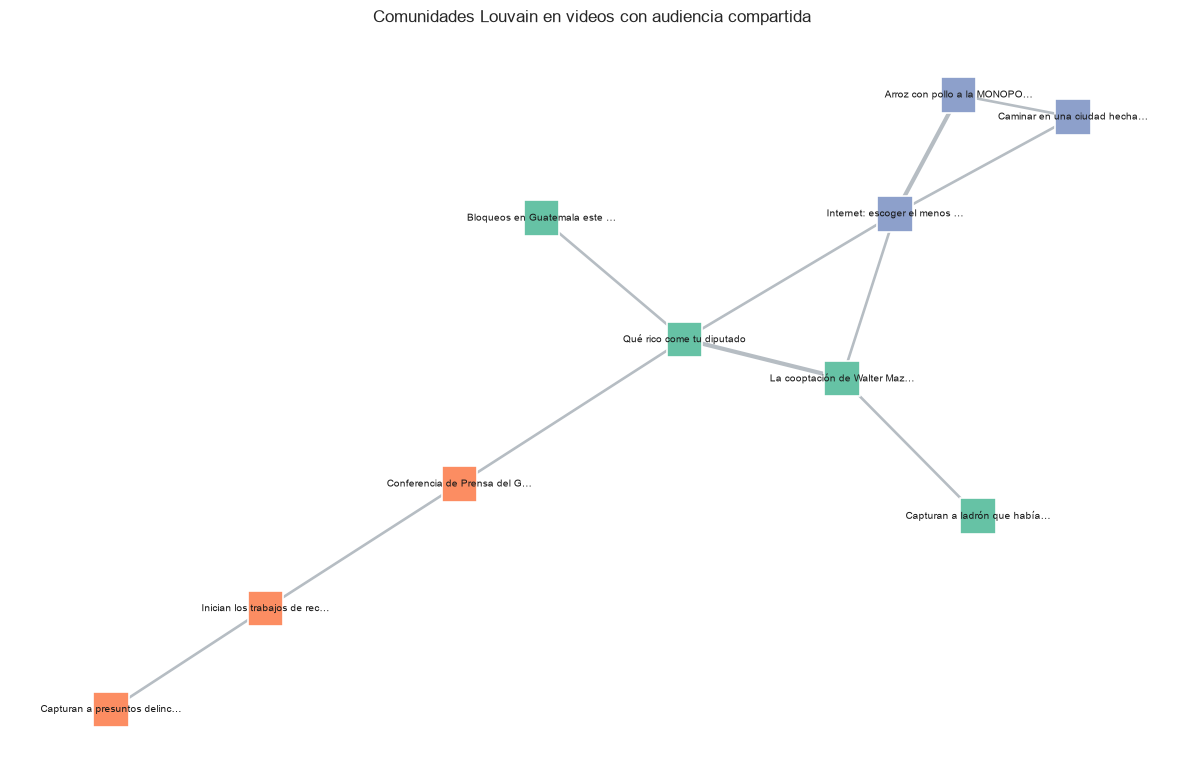

In [31]:
community_by_node = video_membership.set_index("node_id")["community_id"].to_dict()
community_palette = dict(zip(
    sorted(video_membership["community_id"].unique()),
    sns.color_palette("Set2", n_colors=len(video_communities)),
))
community_pos = nx.spring_layout(active_video_graph, seed=42, weight="weight", iterations=100)

fig, ax = plt.subplots(figsize=(12, 8))
nx.draw_networkx_edges(
    active_video_graph, community_pos, ax=ax, edge_color="#7A8793", alpha=0.55,
    width=[0.8 + 1.1 * active_video_graph[u][v]["weight"] for u, v in active_video_graph.edges()],
)
nx.draw_networkx_nodes(
    active_video_graph, community_pos, ax=ax, node_shape="s", node_size=650,
    node_color=[community_palette[community_by_node[n]] for n in active_video_graph],
    edgecolors="white", linewidths=1.2,
)
nx.draw_networkx_labels(
    active_video_graph, community_pos,
    labels={n: shorten(active_video_graph.nodes[n].get("label", n), 28) for n in active_video_graph},
    font_size=7, ax=ax,
)
ax.set_title("Comunidades Louvain en videos con audiencia compartida")
ax.axis("off")
plt.tight_layout()
plt.show()

## 7.5 Caracterización de las comunidades

Se caracterizan todas las comunidades detectadas y se interpretan con mayor detalle las tres más grandes (si existen). La intensidad se mide mediante comentarios recolectados por video. Los temas son palabras frecuentes de `texto_limpio`, pero los comentarios permanecen en su idioma original. El componente de sentimiento se incorpora en el ejercicio 9 con un modelo específico y luego se integra a esta misma tabla.

In [32]:
community_videos = video_membership.assign(
    video_id=video_membership["node_id"].str.removeprefix("video::")
).merge(
    videos[["video_id", "title", "channel_id", "channel_name", "source_query"]],
    on="video_id", how="left", validate="one_to_one",
)
comments_community = comments.merge(
    community_videos[["video_id", "community_id"]], on="video_id", how="inner", validate="many_to_one"
)

community_rows = []
for community_id, group in community_videos.groupby("community_id"):
    video_ids = group["video_id"]
    subset = comments[comments["video_id"].isin(video_ids)]
    top_titles = (
        subset.groupby("video_id").size().sort_values(ascending=False).head(3).index
    )
    title_lookup = group.set_index("video_id")["title"]
    terms = frequency_table(subset["texto_limpio"], ngram=1, top_n=5)["palabra"].tolist()
    community_rows.append({
        "community_id": community_id,
        "videos": group["video_id"].nunique(),
        "canales": group["channel_id"].nunique(),
        "autores": subset["author_channel_id"].nunique(),
        "comentarios": len(subset),
        "comentarios_por_video": len(subset) / group["video_id"].nunique(),
        "canales_principales": "; ".join(group["channel_name"].value_counts().head(3).index.astype(str)),
        "videos_principales": "; ".join(shorten(title_lookup.loc[v], 42) for v in top_titles),
        "temas_frecuentes": ", ".join(terms),
    })
community_profile = pd.DataFrame(community_rows).sort_values(
    ["videos", "comentarios"], ascending=False
)
display(community_profile[["community_id", "videos", "canales", "autores", "comentarios", "comentarios_por_video"]].round(3))
for row in community_profile.itertuples():
    display(Markdown(
        f"**Comunidad {int(row.community_id)}.** Canales: {row.canales_principales}. "
        f"Videos principales: {row.videos_principales}. "
        f"Términos frecuentes: {row.temas_frecuentes}."
    ))

,community_id,videos,canales,autores,comentarios,comentarios_por_video
0,1,4,3,187,225,56.250
1,2,3,2,62,84,28.000
2,3,3,1,29,34,11.333


**Comunidad 1.** Canales: Quorum; PrensaLibreOficial; TN23 Guatemala. Videos principales: Qué rico come tu diputado; La cooptación de Walter Mazariegos en la …; Capturan a ladrón que había quedado graba…. Términos frecuentes: no, pueblo, dinero, diputados, trabajo.

**Comunidad 2.** Canales: Gobierno de la República de Guatemala; Noti7. Videos principales: Inician los trabajos de recuperación del …; Conferencia de Prensa del Gobierno de Gua…; Capturan a presuntos delincuentes disfraz…. Términos frecuentes: no, presidente, guatemala, país, años.

**Comunidad 3.** Canales: Quorum. Videos principales: Arroz con pollo a la MONOPOLIO; Internet: escoger el menos malo; Caminar en una ciudad hecha para carros. Términos frecuentes: no, excelente, empresas, internet, ley.

# 8. Nodos centrales y participantes puente

## 8.1 Medidas elegidas

- **Grado:** diversidad de vecinos; en autores es número de videos y en videos número de autores.
- **Grado ponderado:** volumen de comentarios asociado con el nodo.
- **Intermediación:** proporción de caminos mínimos que pasan por el nodo; identifica candidatos a puente en la estructura observada.
- **PageRank ponderado:** recursividad de conexiones, considerando frecuencia de comentarios.
- **Punto de articulación:** nodo cuya eliminación aumenta el número de componentes.

Estas medidas describen posición estructural. No equivalen a influencia causal, persuasión, aprobación ni popularidad fuera de la muestra.

**Autores con mayor intermediación**

,label,degree,weighted_degree,betweenness,pagerank,is_articulation
98,/@virgiliogarcia3039,2,3,0.072766,0.002722,True
276,/@inge_vergueta,3,3,0.068522,0.002978,True
330,/@josegil3813,2,2,0.055562,0.001861,True
325,/@Jel.Awesh.M,2,3,0.028013,0.003097,False
307,/@hashojea7348,3,4,0.018760,0.004063,True
250,/@franciscoflores3120,2,2,0.018192,0.002055,True
207,/@Alejandro00710,2,2,0.010148,0.002198,False
211,/@MarcosCarillo-b1r,2,2,0.010012,0.002417,True
287,/@moisesvaldez4043,2,2,0.010012,0.002219,True
241,/@eugeneramirez4405,1,6,0.000000,0.004968,False


**Videos con mayor intermediación**

,label,degree,weighted_degree,betweenness,pagerank,is_articulation
578,Qué rico come tu diputado,128,161,0.177748,0.149678,True
468,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,19,25,0.076676,0.022278,True
561,La cooptación de Walter Mazariegos en la USAC,49,50,0.071475,0.056545,True
370,Inician los trabajos de recuperación del Puente Belice II.,32,45,0.058953,0.038104,True
582,Internet: escoger el menos malo,10,12,0.040311,0.011884,True
621,Arroz con pollo a la MONOPOLIO,16,16,0.020005,0.018297,True
336,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,13,14,0.017193,0.015667,True
529,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales,7,7,0.008689,0.008603,True
560,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalhuleu,7,7,0.008689,0.008824,True
495,Caminar en una ciudad hecha para carros,6,6,0.007254,0.007214,True


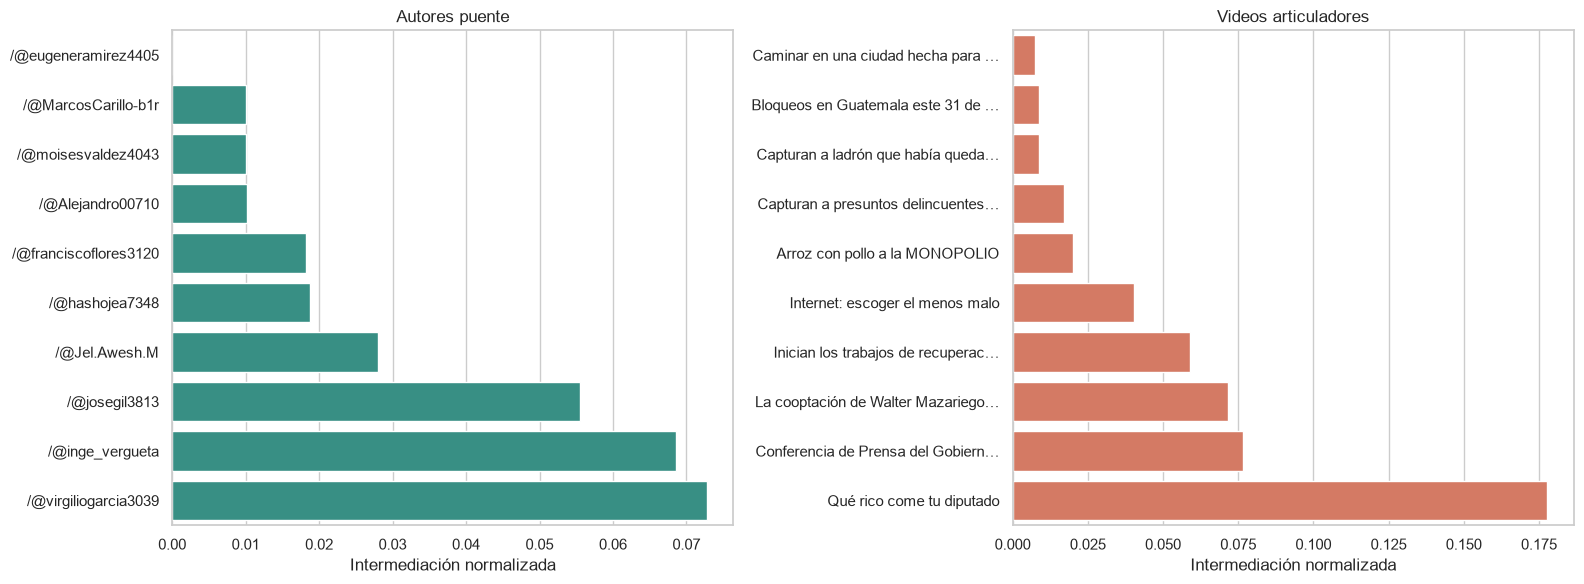

In [33]:
centralities = centrality_table(graph)
author_centrality = centralities.query("node_type == 'author'").sort_values(
    ["betweenness", "degree", "weighted_degree"], ascending=False
)
video_centrality = centralities.query("node_type == 'video'").sort_values(
    ["betweenness", "degree", "weighted_degree"], ascending=False
)

display(Markdown("**Autores con mayor intermediación**"))
display(author_centrality[["label", "degree", "weighted_degree", "betweenness", "pagerank", "is_articulation"]].head(12))
display(Markdown("**Videos con mayor intermediación**"))
display(video_centrality[["label", "degree", "weighted_degree", "betweenness", "pagerank", "is_articulation"]].head(12))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, table, title, color in [
    (axes[0], author_centrality.head(10).sort_values("betweenness"), "Autores puente", COLORS["author"]),
    (axes[1], video_centrality.head(10).sort_values("betweenness"), "Videos articuladores", COLORS["video"]),
]:
    plot_table = table.assign(etiqueta=table["label"].astype(str).map(lambda x: shorten(x, 34)))
    sns.barplot(data=plot_table, x="betweenness", y="etiqueta", color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Intermediación normalizada")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8.2-8.3 Recurrencia, puentes y articulación

In [34]:
recurrent_authors = author_centrality.query("degree > 1").copy()
bridge_authors = author_centrality.query("betweenness > 0").copy()
articulations = centralities.query("is_articulation").sort_values(
    ["node_type", "betweenness"], ascending=[True, False]
)

display(Markdown("**Autores recurrentes: participaron en más de un video**"))
display(recurrent_authors[["label", "degree", "weighted_degree", "betweenness", "is_articulation"]])
display(Markdown("**Puntos de articulación por tipo**"))
display(articulations[["node_type", "label", "degree", "weighted_degree", "betweenness"]])

top_author_bridge = bridge_authors.iloc[0]
top_video_bridge = video_centrality.query("betweenness > 0").iloc[0]
display(Markdown(f"""
- Solo **{len(recurrent_authors)} de {len(author_centrality)} autores** aparecen en más de un video. La recurrencia es excepcional en esta recolección.
- El principal autor candidato a puente por intermediación es **{top_author_bridge['label']}** (grado {int(top_author_bridge['degree'])}). Esto significa que conecta rutas entre videos observados, no que haya provocado el comportamiento de otros.
- El video con mayor intermediación es **{top_video_bridge['label']}** (grado {int(top_video_bridge['degree'])} y {int(top_video_bridge['weighted_degree'])} comentarios asociados).
- Hay **{len(articulations.query("node_type == 'author'"))} autores** y **{len(articulations.query("node_type == 'video'"))} videos** de articulación. Su eliminación segmentaría alguna parte de esta red muestral.
"""))

save_advanced_network_tables(
    author_projection, video_projection, network_metrics, degree_distributions,
    video_membership, centralities,
)

**Autores recurrentes: participaron en más de un video**

,label,degree,weighted_degree,betweenness,is_articulation
98,/@virgiliogarcia3039,2,3,0.072766,True
276,/@inge_vergueta,3,3,0.068522,True
330,/@josegil3813,2,2,0.055562,True
325,/@Jel.Awesh.M,2,3,0.028013,False
307,/@hashojea7348,3,4,0.018760,True
250,/@franciscoflores3120,2,2,0.018192,True
207,/@Alejandro00710,2,2,0.010148,False
211,/@MarcosCarillo-b1r,2,2,0.010012,True
287,/@moisesvaldez4043,2,2,0.010012,True


**Puntos de articulación por tipo**

,node_type,label,degree,weighted_degree,betweenness
98,author,/@virgiliogarcia3039,2,3,0.072766
276,author,/@inge_vergueta,3,3,0.068522
330,author,/@josegil3813,2,2,0.055562
307,author,/@hashojea7348,3,4,0.018760
250,author,/@franciscoflores3120,2,2,0.018192
211,author,/@MarcosCarillo-b1r,2,2,0.010012
287,author,/@moisesvaldez4043,2,2,0.010012
578,video,Qué rico come tu diputado,128,161,0.177748
468,video,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,19,25,0.076676
561,video,La cooptación de Walter Mazariegos en la USAC,49,50,0.071475



- Solo **9 de 332 autores** aparecen en más de un video. La recurrencia es excepcional en esta recolección.
- El principal autor candidato a puente por intermediación es **/@virgiliogarcia3039** (grado 2). Esto significa que conecta rutas entre videos observados, no que haya provocado el comportamiento de otros.
- El video con mayor intermediación es **Qué rico come tu diputado** (grado 128 y 161 comentarios asociados).
- Hay **7 autores** y **15 videos** de articulación. Su eliminación segmentaría alguna parte de esta red muestral.


# 9. Análisis de contenido y sentimiento

## 9.1 Modelo, texto de entrada y precauciones

Se usa [`cardiffnlp/twitter-xlm-roberta-base-sentiment`](https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment), un XLM-R multilingüe entrenado con texto de redes sociales y ajustado para sentimiento en ocho idiomas, incluido español. Se elige frente a un modelo solo en español porque el corpus contiene más de un idioma y **no se traduce ningún texto**.

El modelo recibe `texto_original`; solo sustituye URL y menciones por marcadores según su preprocesamiento recomendado. Conserva mayúsculas, puntuación, negaciones, hashtags y emojis. Produce probabilidades `negative`, `neutral` y `positive`; se define `sentiment_score = P(positive) - P(negative)` en [-1, 1].

Limitaciones del método: fue ajustado con tuits, no comentarios de YouTube; puede fallar con sarcasmo, modismos guatemaltecos, texto mixto o contexto externo. No hay etiquetas humanas en este dataset para estimar desempeño local, por lo que las clases son **salidas del modelo**, no hechos observados.

In [35]:
sentiment_results = analyze_sentiment(
    comments["texto_original"], MODEL_CACHE, batch_size=16, max_length=128
)
comments_sentiment = pd.concat([comments.copy(), sentiment_results], axis=1)
comments_sentiment.to_csv(COMMENTS_SENTIMENT, index=False, encoding="utf-8")

sentiment_counts = (
    comments_sentiment["sentiment_label"].value_counts()
    .reindex(["negative", "neutral", "positive"], fill_value=0)
)
sentiment_summary = pd.DataFrame({
    "comentarios": sentiment_counts,
    "proporción": sentiment_counts / len(comments_sentiment),
})
display(sentiment_summary.style.format({"proporción": "{:.1%}"}))
display(pd.DataFrame([{
    "modelo": MODEL_NAME,
    "score_medio": comments_sentiment["sentiment_score"].mean(),
    "confianza_media": comments_sentiment["sentiment_confidence"].mean(),
    "comentarios": len(comments_sentiment),
}]).round(4))

display(Markdown("**Casos de menor confianza para auditoría cualitativa**"))
display(comments_sentiment.nsmallest(8, "sentiment_confidence")[[
    "texto_original", "sentiment_label", "sentiment_confidence",
    "p_negative", "p_neutral", "p_positive",
]])

,comentarios,proporción
sentiment_label,,
negative,256,63.1%
neutral,58,14.3%
positive,92,22.7%


,modelo,score_medio,confianza_media,comentarios
0,cardiffnlp/twitter-xlm-roberta-base-sentiment,-0.3508,0.7774,406


**Casos de menor confianza para auditoría cualitativa**

,texto_original,sentiment_label,sentiment_confidence,p_negative,p_neutral,p_positive
173,Otto Pérez Leal dejó tirado un paso a desnivel en Molino Las Flores y Neto Bran ni se ha molestado en retomar. \nHay...,negative,0.336299,0.336299,0.336252,0.327449
366,Porque estan aciendo protestas si la gasolina aun subira mas de precio yo claro les edicho que si Nosotros perdemos ...,neutral,0.372083,0.353219,0.372083,0.274698
259,"Me agrado lo que usted a dicho, es cierto hay muchas personas que no piensan en el desarrollo mutuo y en el lugar de...",positive,0.380887,0.368723,0.250390,0.380887
319,paaajaaaasss,positive,0.386179,0.280393,0.333428,0.386179
373,El poeta de el diablo el portillo... y no que muy honesto el pastorcito pues......,positive,0.392704,0.331839,0.275458,0.392704
258,Bienvenido el tren maya 🎉 como hay ineptos que se oponen a esta gran colaboración estamos hablando de desarrollo par...,neutral,0.396956,0.209937,0.396956,0.393107
312,Inglés,neutral,0.409980,0.333770,0.409980,0.256250
38,😮,neutral,0.411171,0.212162,0.411171,0.376667


## 9.2 Comparación por video, canal, consulta y comunidad

Para evitar comparar promedios definidos por uno o dos comentarios, los gráficos por canal y video requieren al menos cinco observaciones. El umbral mejora la estabilidad visual, pero no convierte la muestra en representativa ni constituye una prueba de significancia.

In [36]:
sentiment_by_channel = (
    comments_sentiment.groupby(["channel_id", "channel_name"], dropna=False)
    .agg(n=("comment_id", "size"), score=("sentiment_score", "mean"),
         confianza=("sentiment_confidence", "mean"), negativos=("sentiment_label", lambda s: s.eq("negative").mean()))
    .reset_index().query("n >= 5").sort_values("score")
)
sentiment_by_video = (
    comments_sentiment.groupby(["video_id", "video_title"], dropna=False)
    .agg(n=("comment_id", "size"), score=("sentiment_score", "mean"),
         negativos=("sentiment_label", lambda s: s.eq("negative").mean()))
    .reset_index().query("n >= 5").sort_values("score")
)
sentiment_by_query = (
    comments_sentiment.groupby("source_query", dropna=False)
    .agg(n=("comment_id", "size"), score=("sentiment_score", "mean"))
    .reset_index().query("n >= 5").sort_values("score")
)

sentiment_community = comments_sentiment.merge(
    community_videos[["video_id", "community_id"]], on="video_id", how="inner", validate="many_to_one"
)
community_sentiment = (
    sentiment_community.groupby("community_id")
    .agg(n=("comment_id", "size"), score_sentimiento=("sentiment_score", "mean"),
         confianza_media=("sentiment_confidence", "mean"),
         negativos=("sentiment_label", lambda s: s.eq("negative").mean()),
         neutrales=("sentiment_label", lambda s: s.eq("neutral").mean()),
         positivos=("sentiment_label", lambda s: s.eq("positive").mean()))
    .reset_index()
)
community_profile_complete = community_profile.merge(
    community_sentiment, on="community_id", how="left", validate="one_to_one"
)

display(Markdown("**Canales con al menos 5 comentarios**")); display(sentiment_by_channel.round(3))
display(Markdown("**Videos con al menos 5 comentarios**")); display(sentiment_by_video.round(3))
display(Markdown("**Consultas con al menos 5 comentarios**")); display(sentiment_by_query.round(3))
display(Markdown("**Sentimiento por comunidad**"))
display(community_profile_complete[[
    "community_id", "videos", "autores", "comentarios",
    "score_sentimiento", "confianza_media", "negativos", "neutrales", "positivos",
]].round(3))
display(Markdown("**Caracterización integrada de cada comunidad**"))
for row in community_profile_complete.itertuples():
    display(Markdown(
        f"**Comunidad {int(row.community_id)}:** {int(row.videos)} videos, "
        f"{int(row.autores)} autores y {int(row.comentarios)} comentarios; "
        f"score {row.score_sentimiento:.3f} "
        f"({row.negativos:.1%} negativos, {row.neutrales:.1%} neutrales y {row.positivos:.1%} positivos). "
        f"Temas: {row.temas_frecuentes}. Canales: {row.canales_principales}."
    ))

**Canales con al menos 5 comentarios**

,channel_id,channel_name,n,score,confianza,negativos
7,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,-0.707,0.793,0.857
2,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,7,-0.622,0.706,0.857
3,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,25,-0.569,0.789,0.840
1,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,256,-0.449,0.785,0.684
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,70,-0.209,0.757,0.543
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,14,-0.193,0.712,0.500
5,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,25,0.567,0.790,0.080


**Videos con al menos 5 comentarios**

,video_id,video_title,n,score,negativos
11,is3Mk5oC19g,Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalhuleu,7,-0.707,0.857
10,b_Hkrkl3adA,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales,7,-0.622,0.857
14,n8iP75gIpmw,Qué rico come tu diputado,161,-0.616,0.783
4,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo,25,-0.569,0.840
5,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,25,-0.419,0.640
12,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,50,-0.315,0.600
8,WIUZtitfLRw,Caminar en una ciudad hecha para carros,6,-0.199,0.500
0,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,14,-0.193,0.500
17,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,16,-0.176,0.562
2,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,45,-0.092,0.489


**Consultas con al menos 5 comentarios**

...

,community_id,videos,autores,comentarios,score_sentimiento,confianza_media,negativos,neutrales,positivos
0,1,4,187,225,-0.552,0.786,0.747,0.142,0.111
1,2,3,62,84,-0.206,0.749,0.536,0.179,0.286
2,3,3,29,34,-0.098,0.771,0.471,0.147,0.382


**Caracterización integrada de cada comunidad**

**Comunidad 1:** 4 videos, 187 autores y 225 comentarios; score -0.552 (74.7% negativos, 14.2% neutrales y 11.1% positivos). Temas: no, pueblo, dinero, diputados, trabajo. Canales: Quorum; PrensaLibreOficial; TN23 Guatemala.

**Comunidad 2:** 3 videos, 62 autores y 84 comentarios; score -0.206 (53.6% negativos, 17.9% neutrales y 28.6% positivos). Temas: no, presidente, guatemala, país, años. Canales: Gobierno de la República de Guatemala; Noti7.

**Comunidad 3:** 3 videos, 29 autores y 34 comentarios; score -0.098 (47.1% negativos, 14.7% neutrales y 38.2% positivos). Temas: no, excelente, empresas, internet, ley. Canales: Quorum.

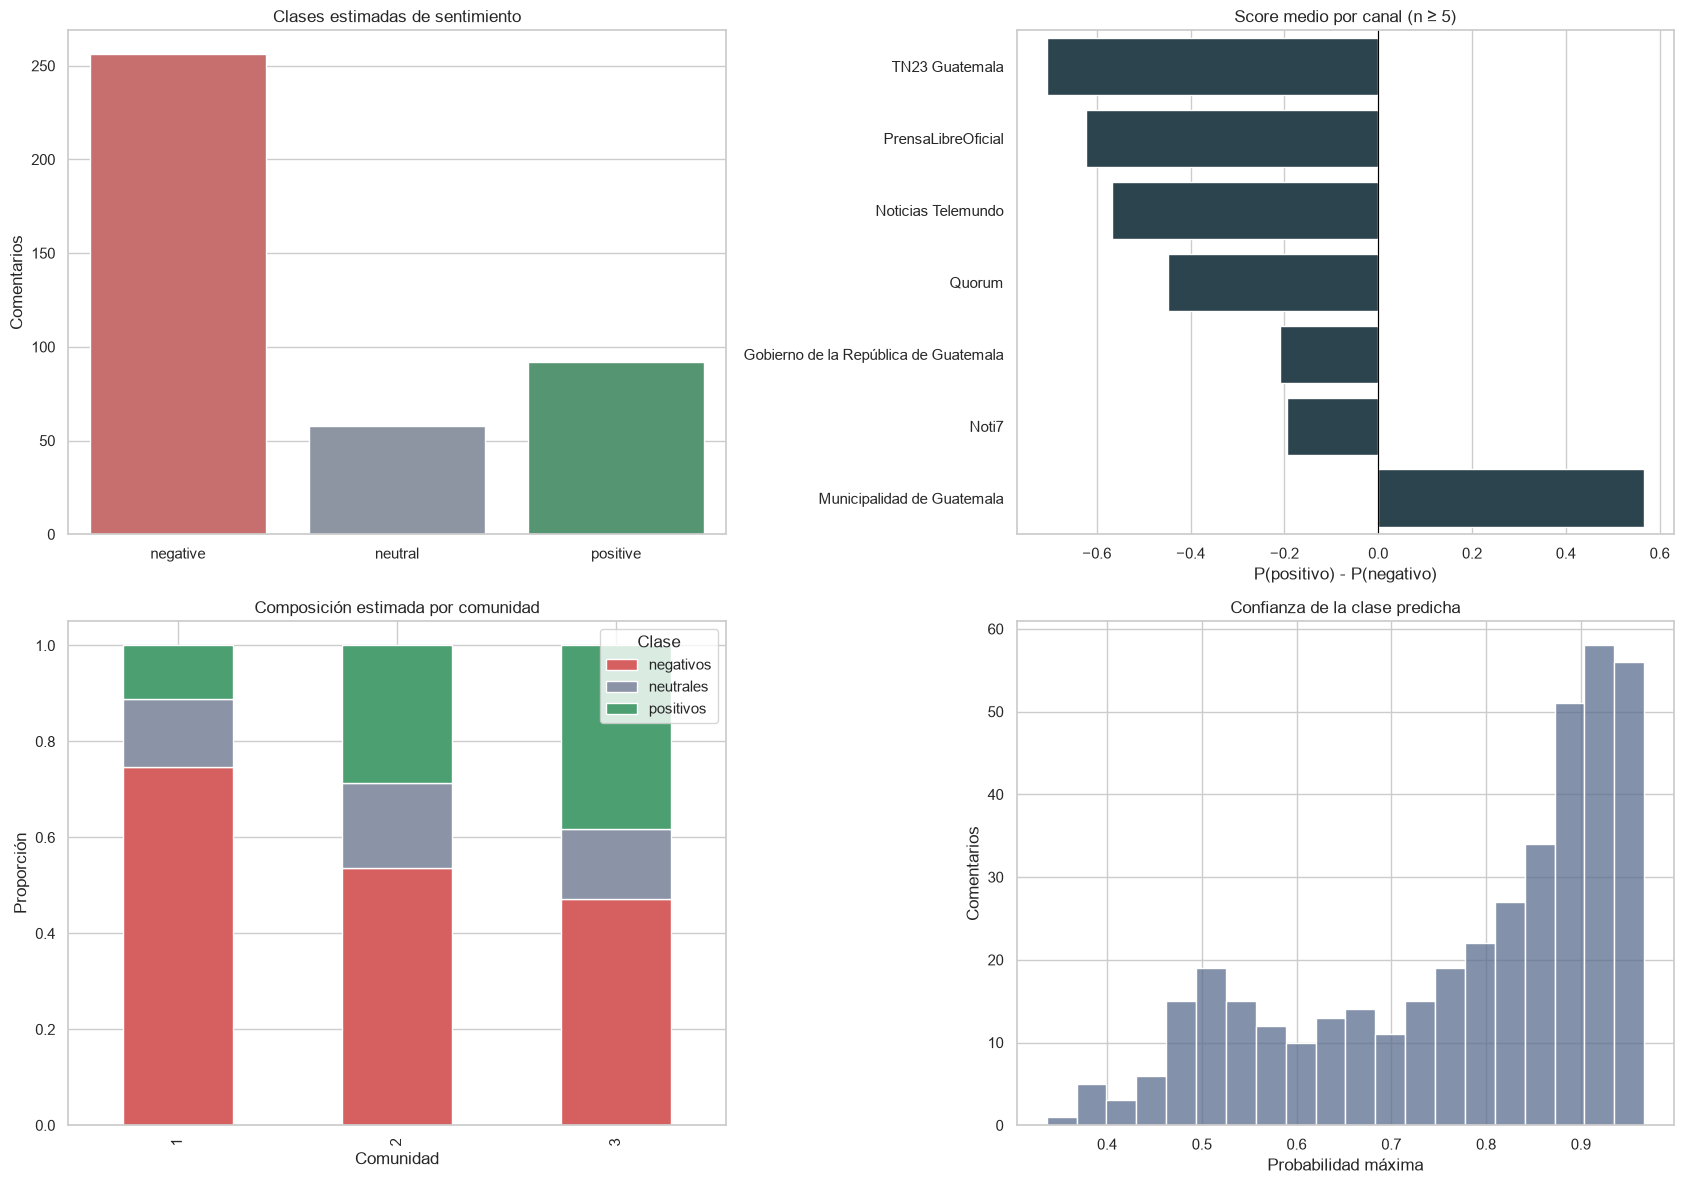

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,
            hue=sentiment_counts.index, palette={"negative": "#D65F5F", "neutral": "#8A94A6", "positive": "#4C9F70"},
            legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Clases estimadas de sentimiento")
axes[0, 0].set_xlabel(""); axes[0, 0].set_ylabel("Comentarios")

channel_plot = sentiment_by_channel.assign(
    etiqueta=sentiment_by_channel["channel_name"].astype(str).map(lambda x: shorten(x, 38))
)
sns.barplot(data=channel_plot, x="score", y="etiqueta", color=COLORS["accent"], ax=axes[0, 1])
axes[0, 1].axvline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("Score medio por canal (n ≥ 5)")
axes[0, 1].set_xlabel("P(positivo) - P(negativo)"); axes[0, 1].set_ylabel("")

community_props = community_sentiment.set_index("community_id")[["negativos", "neutrales", "positivos"]]
community_props.plot(kind="bar", stacked=True, color=["#D65F5F", "#8A94A6", "#4C9F70"], ax=axes[1, 0])
axes[1, 0].set_title("Composición estimada por comunidad")
axes[1, 0].set_xlabel("Comunidad"); axes[1, 0].set_ylabel("Proporción"); axes[1, 0].legend(title="Clase")

sns.histplot(comments_sentiment["sentiment_confidence"], bins=20, color="#5B6C8F", ax=axes[1, 1])
axes[1, 1].set_title("Confianza de la clase predicha")
axes[1, 1].set_xlabel("Probabilidad máxima"); axes[1, 1].set_ylabel("Comentarios")

plt.tight_layout()
plt.show()

## 9.3 Hallazgos de contenido y sentimiento

In [38]:
most_negative_channel = sentiment_by_channel.iloc[0]
most_positive_channel = sentiment_by_channel.iloc[-1]
largest_community = community_profile_complete.sort_values(["videos", "comentarios"], ascending=False).iloc[0]
display(Markdown(f"""
- El modelo clasifica **{sentiment_counts['negative']} comentarios como negativos ({sentiment_counts['negative']/len(comments_sentiment):.1%})**, {sentiment_counts['neutral']} neutrales y {sentiment_counts['positive']} positivos. El score medio es **{comments_sentiment['sentiment_score'].mean():.3f}** y la confianza media **{comments_sentiment['sentiment_confidence'].mean():.3f}**.
- Entre canales con al menos cinco comentarios, el score va de **{most_negative_channel['score']:.3f}** en *{most_negative_channel['channel_name']}* (n={int(most_negative_channel['n'])}) a **{most_positive_channel['score']:.3f}** en *{most_positive_channel['channel_name']}* (n={int(most_positive_channel['n'])}). Es una asociación descriptiva entre comentarios recolectados y canal; puede reflejar tema, audiencia, selección de videos o error del modelo.
- La comunidad más grande contiene **{int(largest_community['videos'])} videos**, {int(largest_community['autores'])} autores y {int(largest_community['comentarios'])} comentarios; sus términos frecuentes son **{largest_community['temas_frecuentes']}** y su score de sentimiento es **{largest_community['score_sentimiento']:.3f}**.
- Las diferencias de sentimiento no demuestran que un canal o tema cause una reacción. Sin muestreo aleatorio, etiquetas humanas y control de variables, no procede una inferencia poblacional o causal.
"""))


- El modelo clasifica **256 comentarios como negativos (63.1%)**, 58 neutrales y 92 positivos. El score medio es **-0.351** y la confianza media **0.777**.
- Entre canales con al menos cinco comentarios, el score va de **-0.707** en *TN23 Guatemala* (n=7) a **0.567** en *Municipalidad de Guatemala* (n=25). Es una asociación descriptiva entre comentarios recolectados y canal; puede reflejar tema, audiencia, selección de videos o error del modelo.
- La comunidad más grande contiene **4 videos**, 187 autores y 225 comentarios; sus términos frecuentes son **no, pueblo, dinero, diputados, trabajo** y su score de sentimiento es **-0.552**.
- Las diferencias de sentimiento no demuestran que un canal o tema cause una reacción. Sin muestreo aleatorio, etiquetas humanas y control de variables, no procede una inferencia poblacional o causal.


# 10. Interpretación, limitaciones y conclusiones

## 10.1 Participación y consumo observado

In [39]:
top_video_share = comments_by_video.iloc[0]["comentarios"] / len(comments)
shared_video_nodes = active_video_graph.number_of_nodes()
display(Markdown(f"""
Los datos describen un consumo **concentrado y fragmentado**. El video más comentado reúne {top_video_share:.1%} de los comentarios recolectados; {int(bip['isolates'])} nodos bipartitos están aislados y solo {shared_video_nodes} videos participan en alguna relación de audiencia compartida. A la vez, un video con muchos autores crea una proyección autor-autor densa y altamente transitiva. Por ello, la densidad de esa proyección refleja principalmente copresencia en pocos contenidos, no una comunidad social cohesionada.

Los {len(recurrent_authors)} autores recurrentes y los puntos de articulación aportan la evidencia más directa de conexión entre contenidos. Las comunidades Louvain ordenan los pocos solapamientos observados en grupos de videos, mientras el análisis textual muestra qué vocabulario y sentimiento estimado acompañan esos grupos.
"""))


Los datos describen un consumo **concentrado y fragmentado**. El video más comentado reúne 39.7% de los comentarios recolectados; 274 nodos bipartitos están aislados y solo 10 videos participan en alguna relación de audiencia compartida. A la vez, un video con muchos autores crea una proyección autor-autor densa y altamente transitiva. Por ello, la densidad de esa proyección refleja principalmente copresencia en pocos contenidos, no una comunidad social cohesionada.

Los 9 autores recurrentes y los puntos de articulación aportan la evidencia más directa de conexión entre contenidos. Las comunidades Louvain ordenan los pocos solapamientos observados en grupos de videos, mientras el análisis textual muestra qué vocabulario y sentimiento estimado acompañan esos grupos.


## 10.2 Limitaciones obligatorias

1. **Cobertura de comentarios:** solo se analizan los 406 comentarios principales entregados. Un video sin comentarios en el CSV no necesariamente carece de ellos en YouTube.
2. **Selección por consultas y canales:** `source_query` y `source_group` definen una muestra dirigida, no aleatoria; los temas y canales ausentes no tuvieron la misma probabilidad de inclusión.
3. **Fechas relativas:** `published_text` y `published_time` dependen del momento de captura y no permiten reconstruir con precisión la dinámica temporal.
4. **Conteos observados:** vistas, me gusta y respuestas son fotografías de distintos acumulados; pueden crecer después y no comparten necesariamente la misma ventana de exposición.
5. **Falta de relaciones explícitas:** `reply_count` no identifica a quien respondió. Las aristas expresan participación o coparticipación, nunca respuesta, amistad, conversación o aprobación.
6. **Concentración:** pocos videos aportan gran parte de los comentarios. Las métricas y el sentimiento global están muy influidos por esos contenidos.
7. **Identidad y texto:** IDs son más estables que nombres, pero puede haber cuentas eliminadas o múltiples cuentas por persona. El modelo de sentimiento puede fallar por dominio, sarcasmo, modismos, multilingüismo y falta de contexto.
8. **Comunidades y centralidad:** dependen de decisiones de modelado, pesos, algoritmo y cobertura. Son estructuras de esta red observada, no segmentos naturales o influencia causal.

## 10.3 Descripción, asociación e inferencia

| Nivel | Qué sí se sostiene | Qué no se sostiene |
|---|---|---|
| Descripción | conteos, distribuciones, aristas, componentes, centralidades y salidas del modelo en estos CSV | que estos valores representen todo YouTube o toda Guatemala |
| Asociación | en la muestra, ciertos videos comparten autores; vistas y comentarios tienen la correlación reportada; el score difiere entre grupos | que un canal, tema o número de vistas cause participación o sentimiento |
| Inferencia | no se realiza inferencia poblacional ni causal por ausencia de muestreo probabilístico, diseño experimental y etiquetas humanas | generalizaciones a todos los usuarios, votantes, habitantes o consumidores de noticias |

## 10.4 Conclusiones integradas y cierre de las preguntas del laboratorio

In [40]:
top_author_names = ", ".join(recurrent_authors.head(3)["label"].astype(str))
top_community_terms = "; ".join(
    f"C{int(row.community_id)}: {row.temas_frecuentes}"
    for row in community_profile_complete.head(3).itertuples()
)
display(Markdown(f"""
1. **Concentración:** *{comments_by_video.iloc[0]['title']}* y *{comments_by_channel.iloc[0]['channel_name']}* concentran la mayor participación observada. El primer video aporta {top_video_share:.1%} de todos los comentarios.
2. **Audiencias compartidas:** existen, pero son limitadas entre videos: la proyección video-video tiene {video_projection.number_of_edges()} aristas y {nx.number_of_isolates(video_projection)} aislados. La gran proyección autor-autor surge sobre todo de coincidencias dentro de videos populares.
3. **Puentes:** los autores recurrentes principales son {top_author_names}; su intermediación y condición de articulación identifican conexión estructural, no influencia causal.
4. **Comunidades y contenido:** Louvain encuentra {len(video_communities)} comunidades en los {active_video_graph.number_of_nodes()} videos con audiencia compartida (modularidad {video_modularity:.3f}). Sus términos principales son {top_community_terms}.
5. **Sentimiento:** el modelo multilingüe estima predominio negativo ({sentiment_counts['negative']/len(comments_sentiment):.1%}), pero el resultado está dominado por los videos con más comentarios y sujeto a error de dominio. Se conserva el texto original y no se traduce.
6. **Visibilidad frente a participación:** la correlación de Spearman entre vistas y comentarios es {rho:.3f} (p={p_value:.3f}); en esta muestra no hay evidencia de una asociación monotónica fuerte. Vistas y comentarios tampoco comparten cobertura temporal ni procedimiento de recolección.
7. **Conclusión general:** la evidencia permite describir una red de participación concentrada, con poco cruce entre contenidos y unos cuantos nodos puente. No permite afirmar relaciones sociales entre autores, causalidad, opinión pública ni comportamiento de toda la población guatemalteca.
"""))


1. **Concentración:** *Qué rico come tu diputado* y *Quorum* concentran la mayor participación observada. El primer video aporta 39.7% de todos los comentarios.
2. **Audiencias compartidas:** existen, pero son limitadas entre videos: la proyección video-video tiene 11 aristas y 283 aislados. La gran proyección autor-autor surge sobre todo de coincidencias dentro de videos populares.
3. **Puentes:** los autores recurrentes principales son /@virgiliogarcia3039, /@inge_vergueta, /@josegil3813; su intermediación y condición de articulación identifican conexión estructural, no influencia causal.
4. **Comunidades y contenido:** Louvain encuentra 3 comunidades en los 10 videos con audiencia compartida (modularidad 0.405). Sus términos principales son C1: no, pueblo, dinero, diputados, trabajo; C2: no, presidente, guatemala, país, años; C3: no, excelente, empresas, internet, ley.
5. **Sentimiento:** el modelo multilingüe estima predominio negativo (63.1%), pero el resultado está dominado por los videos con más comentarios y sujeto a error de dominio. Se conserva el texto original y no se traduce.
6. **Visibilidad frente a participación:** la correlación de Spearman entre vistas y comentarios es 0.080 (p=0.170); en esta muestra no hay evidencia de una asociación monotónica fuerte. Vistas y comentarios tampoco comparten cobertura temporal ni procedimiento de recolección.
7. **Conclusión general:** la evidencia permite describir una red de participación concentrada, con poco cruce entre contenidos y unos cuantos nodos puente. No permite afirmar relaciones sociales entre autores, causalidad, opinión pública ni comportamiento de toda la población guatemalteca.
